## Importing all the libraries

In [24]:
import re
import json
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.errors import TopologicalError
import matplotlib.pyplot as plt
import os
from pathlib import Path
import fiona

## Define the base directory

In [25]:
# ----------------------------
# Base directory
# ----------------------------
base_path = Path("/Users/srijankumarjha/Desktop/Validation") #<- Change this location to where input data is stored
os.listdir(base_path)

['.DS_Store', 'Validation_AIS_Satellite.ipynb', 'Data']

## Defining paths to all the input files
All input files are stored inside a single base directory (`base_path`).
Each dataset (AIS predictions and ground truth) is referenced using
`pathlib.Path`, which makes file handling safe and platform-independent.

If you move the data to a different location, you only need to update
`base_path`. All other paths will update automatically.

Before running the analysis, the code checks that all required files exist.
If any file is missing, Python raises a clear error message.

In [26]:
# ----------------------------
# AIS prediction files (HTML)
# ----------------------------
kmeans_html_path      = base_path/"Data/AIS With Anchoring/KMEANS_2_WAY.html"
DBSCAN_html_path      = base_path/"Data/AIS With Anchoring/DBSCAN.html"
Spectral_html_path    = base_path/"Data/AIS With Anchoring/Spectral_Clustering_2_way.html"

# ----------------------------
# AIS prediction files (GeoPackage, anchorage removed)
# ----------------------------
kmeans_gpkg_no_anchor   = base_path/"Data/AIS Without Anchoring/Kmeans_no_anchor.gpkg"
DBSCAN_gpkg_no_anchor   = base_path/"Data/AIS Without Anchoring/DBSCAN_no_anchor.gpkg"
Spectral_gpkg_no_anchor = base_path/"Data/AIS Without Anchoring/Spectral_no_anchor.gpkg"

# ----------------------------
# Ground-truth files
# ----------------------------
sam_gpkg      = base_path/"Data/Ground Truth/SAM_polygons.gpkg"
shipnext_gpkg = base_path/"Data/Ground Truth/shipnext_polygons.gpkg"

#Validate that all files exist
ALL_INPUT_FILES = [
    kmeans_html_path,
    DBSCAN_html_path,
    Spectral_html_path,
    kmeans_gpkg_no_anchor,
    kmeans_gpkg_no_anchor,
    Spectral_gpkg_no_anchor,
    sam_gpkg,
    shipnext_gpkg,
]

for file_path in ALL_INPUT_FILES:
  if not file_path.exists():
    raise FileNotFoundError(f"Missing input file: {file_path}")


## Validation with SAM output

### Validation of AIS against SAM

Pipeline:
- Load SAM from GeoPackage
- Extract AIS polygons from HTML
- Reproject both to the same metric CRS
- Overlay sanity plot
- Compute best-match IOU per AIS polygon
- Precision/Recall/F1 at a user-defined IoU threshold
- Diagnostic plot

In [27]:
# ----------------------------
# Load SAM
# ----------------------------
def load_first_layer_gpkg(gpkg_path: Path, default_epsg: int = 4326) -> gpd.GeoDataFrame:
    """
    Load the first layer from a GeoPackage.
    If CRS is missing, assume EPSG:4326 (lat/lon).
    """
    gpkg_path = Path(gpkg_path)

    if not gpkg_path.exists():
        raise FileNotFoundError(f"GeoPackage not found: {gpkg_path}")

    layers = fiona.listlayers(str(gpkg_path))
    if not layers:
        raise ValueError(f"No layers found inside: {gpkg_path}")

    gdf = gpd.read_file(str(gpkg_path), layer=layers[0])

    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=default_epsg)

    return gdf

# ----------------------------
# Extract AIS Polygons from Folium/Leaflet HTML
# ----------------------------
def parse_cluster_id(text: str):
    """Extract 'Cluster <number>' if present in tooltip text."""
    if not text:
        return None
    m = re.search(r"Cluster\s+(\d+)", text)
    return int(m.group(1)) if m else None


def load_ais_from_html(html_path: Path, crs: str = "EPSG:4326") -> gpd.GeoDataFrame:
    """
    Read an HTML map export (Folium/Leaflet) and extract polygons.

    Looks for:
      L.polygon([[lat, lon], [lat, lon], ...], {...})
    and tooltips:
      bindTooltip(`<div> ... </div>`)
    """
    html_path = Path(html_path)

    if not html_path.exists():
        raise FileNotFoundError(f"HTML file not found: {html_path}")

    html_text = html_path.read_text(encoding="utf-8")

    poly_blocks = re.findall(
        r"L\.polygon\(\s*(\[\[.*?\]\])\s*,\s*\{",
        html_text,
        flags=re.DOTALL
    )

    tooltips = re.findall(
        r"bindTooltip\(\s*`<div>\s*(.*?)\s*</div>`",
        html_text,
        flags=re.DOTALL
    )

    polygons = []
    cluster_ids = []

    for i, block in enumerate(poly_blocks):
        coords_latlon = json.loads(block)              # [[lat, lon], ...]
        coords_lonlat = [(c[1], c[0]) for c in coords_latlon]  # (lon, lat)

        poly = Polygon(coords_lonlat)
        if not poly.is_valid:
            poly = poly.buffer(0)

        polygons.append(poly)

        tip = tooltips[i] if i < len(tooltips) else None
        cluster_ids.append(parse_cluster_id(tip))

    ais = gpd.GeoDataFrame({"cluster_id": cluster_ids}, geometry=polygons, crs=crs)
    return ais


# ----------------------------
# Reproject both datasets to the same metric CRS
# ----------------------------
def to_metric_crs(sam: gpd.GeoDataFrame, ais: gpd.GeoDataFrame, metric_crs: str) -> tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """
    Reproject both layers into a metric CRS (meters).
    This is necessary for area-based metrics like IoU.
    """
    return sam.to_crs(metric_crs), ais.to_crs(metric_crs)


# ----------------------------
# Overlay sanity plot
# ----------------------------
def plot_overlay_check(sam_m: gpd.GeoDataFrame, ais_m: gpd.GeoDataFrame, title: str) -> None:
    """Quick check that layers overlap correctly after CRS conversion."""
    fig, ax = plt.subplots(figsize=(10, 10))

    sam_m.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=1, label="Ground Truth (blue)")
    ais_m.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1, alpha=0.7, label="AIS (red)))")

    ax.set_title(title)
    ax.legend()
    plt.show()

# ----------------------------
# IoU + best match per AIS polygon
# ----------------------------
def safe_iou(poly_a, poly_b) -> float:
    """Compute IoU safely (handles geometry issues)."""
    try:
        inter_area = poly_a.intersection(poly_b).area
        union_area = poly_a.union(poly_b).area
    except TopologicalError:
        poly_a = poly_a.buffer(0)
        poly_b = poly_b.buffer(0)
        inter_area = poly_a.intersection(poly_b).area
        union_area = poly_a.union(poly_b).area

    if union_area == 0:
        return 0.0
    return float(inter_area / union_area)


def best_iou_matches(ais_m: gpd.GeoDataFrame, gt_m: gpd.GeoDataFrame) -> pd.DataFrame:
    """
    For each AIS polygon, find the ground truth polygon with the highest IoU.
    Returns a DataFrame with best_gt_idx and best_iou per AIS polygon.
    """
    gt_sindex = gt_m.sindex
    rows = []

    for ais_idx, ais_geom in enumerate(ais_m.geometry):
        candidate_idx = list(gt_sindex.intersection(ais_geom.bounds))

        best_iou_val = 0.0
        best_gt_idx = None

        for gt_idx in candidate_idx:
            gt_geom = gt_m.geometry.iloc[gt_idx]

            if not ais_geom.intersects(gt_geom):
                continue

            score = safe_iou(ais_geom, gt_geom)
            if score > best_iou_val:
                best_iou_val = score
                best_gt_idx = int(gt_idx)

        rows.append({
            "ais_idx": ais_idx,
            "cluster_id": ais_m.iloc[ais_idx].get("cluster_id", None),
            "best_gt_idx": best_gt_idx,
            "best_iou": best_iou_val
        })

    return pd.DataFrame(rows)

# ----------------------------
# Precision/Recall/F1 at user threshold
# ----------------------------
def prf_at_threshold(match_df: pd.DataFrame, gt_count: int, iou_threshold: float) -> dict:
    """
    Compute TP, FP, FN, precision, recall, f1 for a chosen IoU threshold.
    """
    tp_mask = match_df["best_iou"] >= iou_threshold

    tp = int(tp_mask.sum())
    fp = int((~tp_mask).sum())

    matched_gt = set(match_df.loc[tp_mask, "best_gt_idx"].dropna().astype(int).tolist())
    fn = int(gt_count - len(matched_gt))

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0

    return {
        "iou_threshold": iou_threshold,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ----------------------------
# Diagnostic plot: AIS red, SAM blue, TP black
# ----------------------------
def plot_tp_fp(
    gt_m: gpd.GeoDataFrame,
    ais_m: gpd.GeoDataFrame,
    match_df: pd.DataFrame,
    iou_threshold: float,
    title: str
) -> None:
    """
    Plot:
      - GT in blue
      - All AIS in red
      - True Positives (IoU >= threshold) highlighted in black
    """
    ais_plot = ais_m.copy()
    ais_plot["best_iou"] = match_df["best_iou"].values
    ais_plot["is_tp"] = ais_plot["best_iou"] >= iou_threshold

    fig, ax = plt.subplots(figsize=(10, 10))

    # Ground truth
    gt_m.plot(ax=ax, edgecolor="blue", facecolor="none", linewidth=1, label="Ground Truth (blue)")

    # All AIS (black)
    ais_plot.plot(ax=ax, edgecolor="red", facecolor="none", linewidth=1, alpha=0.5, label="AIS (red)")

    # TP (red)
    ais_plot[ais_plot["is_tp"]].plot(ax=ax, edgecolor="black", facecolor="none", linewidth=2, label="TP (black)")

    ax.set_title(title)
    ax.legend()
    plt.show()


In [28]:
# ----------------------------
# Prepare function for AIS GeoPackage (Anchorage Removed)
# ----------------------------
def prepare_validation_once_gpkg(
    method_name: str,
    ais_gpkg_path,
    gt_gpkg_path,
    metric_crs: str,
    do_overlay_plot: bool = True,
):
    """
    AIS comes from a GeoPackage instead of HTML.
    Heavy steps run ONCE:
      load gt + load AIS + reproject + overlay check + IoU best matches
    """
    gt = load_first_layer_gpkg(gt_gpkg_path)   # reused
    ais = load_first_layer_gpkg(ais_gpkg_path)   # reused

    gt_m, ais_m = to_metric_crs(gt, ais, metric_crs)

    if do_overlay_plot:
        plot_overlay_check(gt_m, ais_m, title=f"Overlay check: SAM vs {method_name} (no anchors)")

    match_df = best_iou_matches(ais_m, gt_m)

    return {
        "method": method_name,
        "gt_m": gt_m,
        "ais_m": ais_m,
        "match_df": match_df,
    }


In [29]:
# ----------------------------
# Function to run preparation
# ----------------------------
def prepare_validation_once(
    method_name: str,
    ais_html_path,
    gt_gpkg_path,
    metric_crs: str,
    do_overlay_plot: bool = True,
):
    """
    Runs the heavy steps ONCE:
      load gt + load AIS + reproject + overlay check + IoU best matches
    Returns a dictionary you can reuse for multiple thresholds.
    """
    gt = load_first_layer_gpkg(gt_gpkg_path)
    ais = load_ais_from_html(ais_html_path)

    gt_m, ais_m = to_metric_crs(gt, ais, metric_crs)

    if do_overlay_plot:
        plot_overlay_check(gt_m, ais_m, title=f"Overlay check: SAM vs {method_name}")

    match_df = best_iou_matches(ais_m, gt_m)

    return {
        "method": method_name,
        "gt_m": gt_m,
        "ais_m": ais_m,
        "match_df": match_df,
    }

# ----------------------------
# Evaluate for thresholds
# ----------------------------
def evaluate_threshold(prepared: dict, iou_threshold: float, make_tp_plot: bool = True) -> dict:
    """
    Computes metrics and makes TP plot for given threshold,
    without redoing overlay / IoU matching.
    """
    gt_m = prepared["gt_m"]
    ais_m = prepared["ais_m"]
    match_df = prepared["match_df"]
    method_name = prepared["method"]

    metrics = prf_at_threshold(match_df, gt_count=len(gt_m), iou_threshold=iou_threshold)

    if make_tp_plot:
        plot_tp_fp(
            gt_m=gt_m,
            ais_m=ais_m,
            match_df=match_df,
            iou_threshold=iou_threshold,
            title=f"{method_name}: Ground Truth (blue), AIS (black), TP (red) @ IoU ≥ {iou_threshold}"
        )

    return {
        "metrics": metrics
    }



### A. Validation of Kmeans against SAM

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


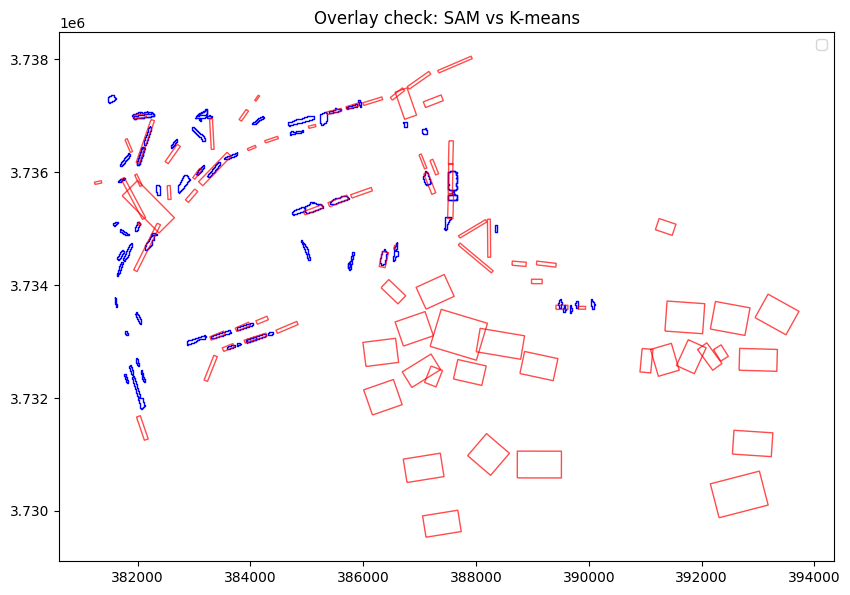

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


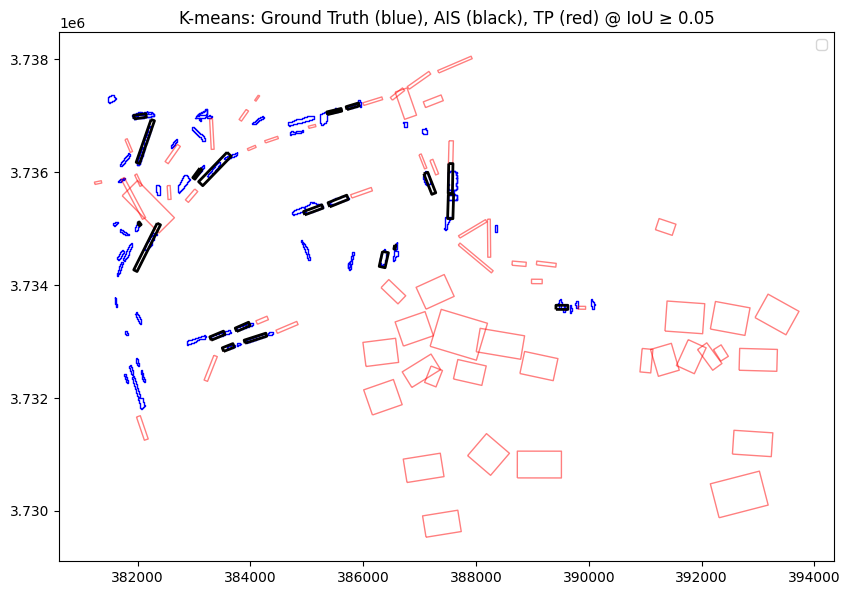

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


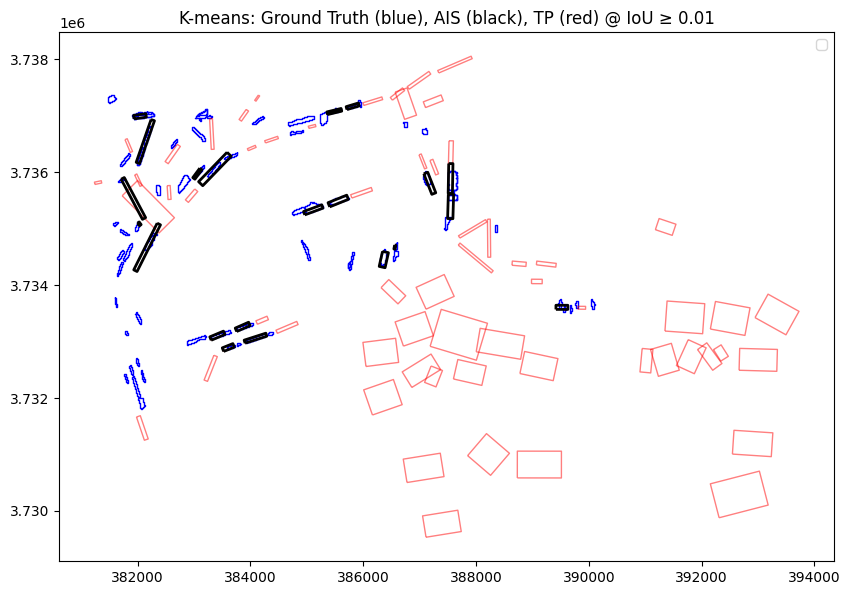

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


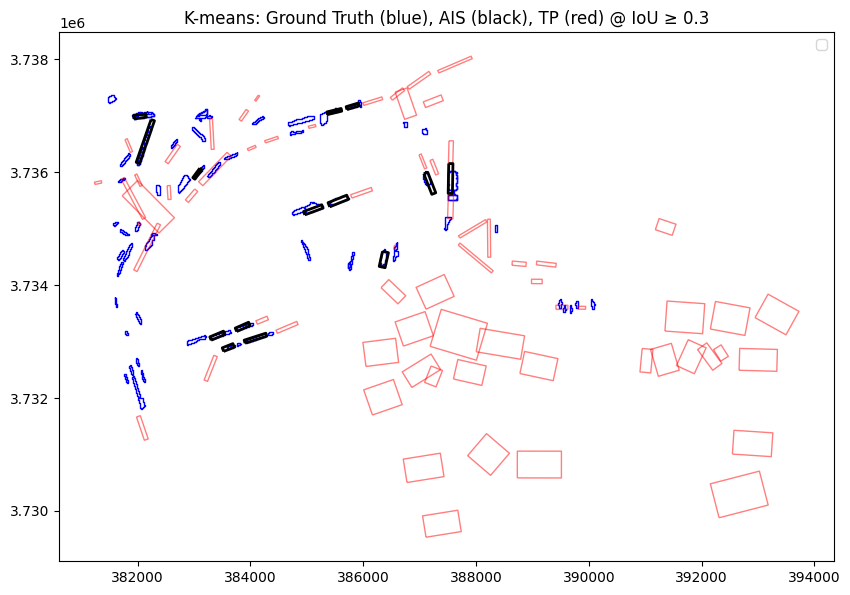

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


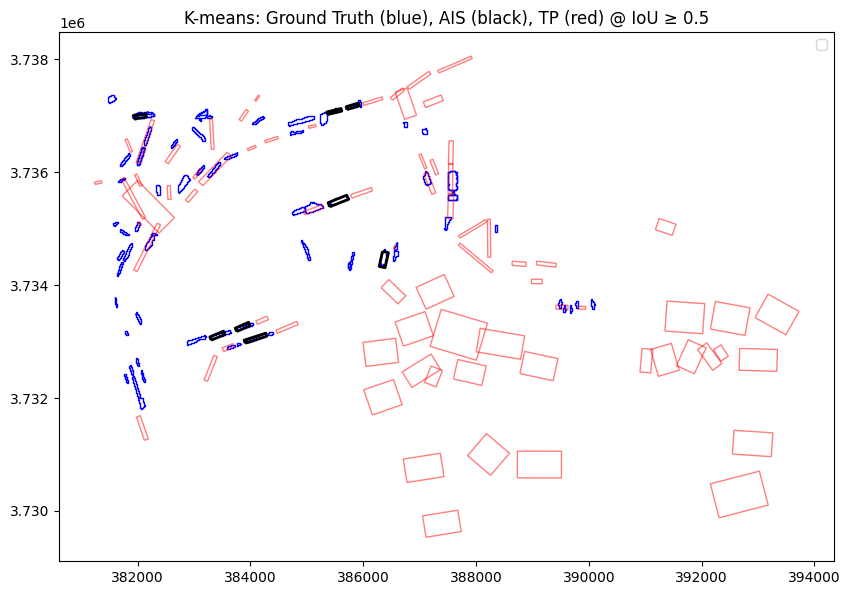

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,K-means,0.05,20,62,53,0.243902,0.273973,0.258065
1,K-means,0.01,21,61,52,0.256098,0.287671,0.270968
2,K-means,0.30,14,68,59,0.170732,0.191781,0.180645
3,K-means,0.50,8,74,65,0.097561,0.109589,0.103226


In [30]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.01, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once(
    method_name="K-means",
    ais_html_path=kmeans_html_path,
    gt_gpkg_path=sam_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]



### B. Validation of DBSCAN against SAM

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


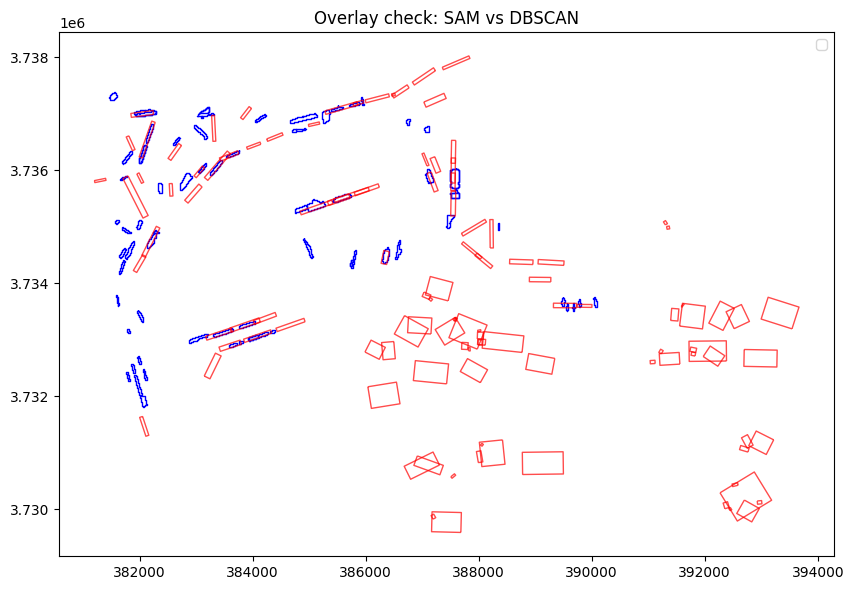

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


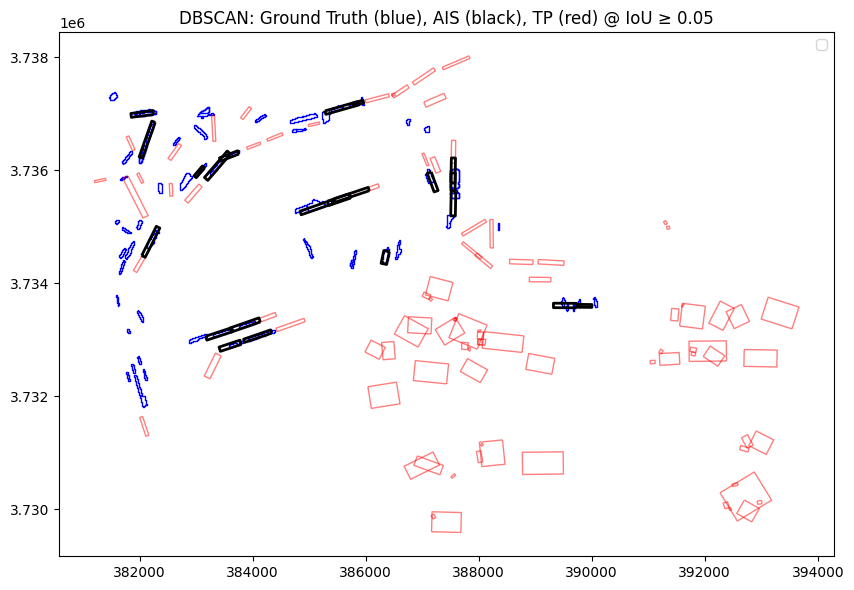

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


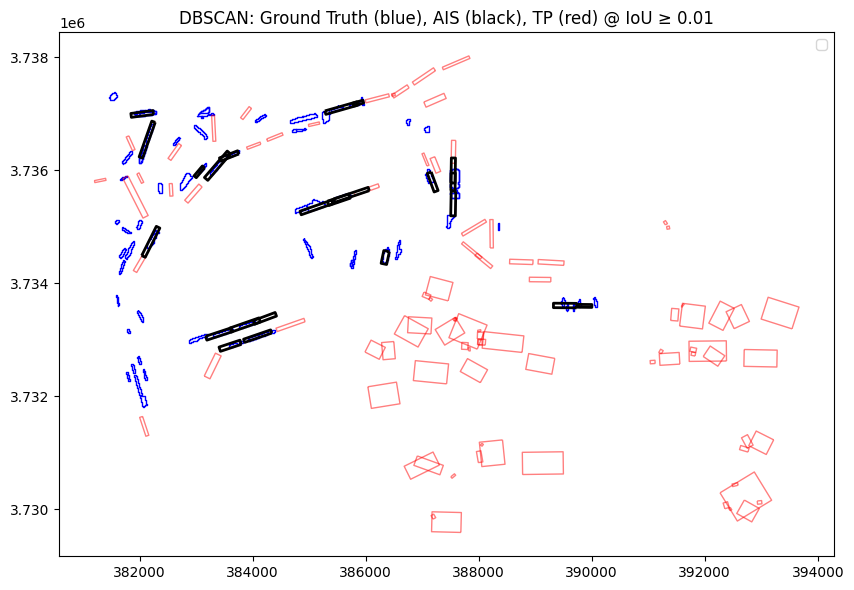

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


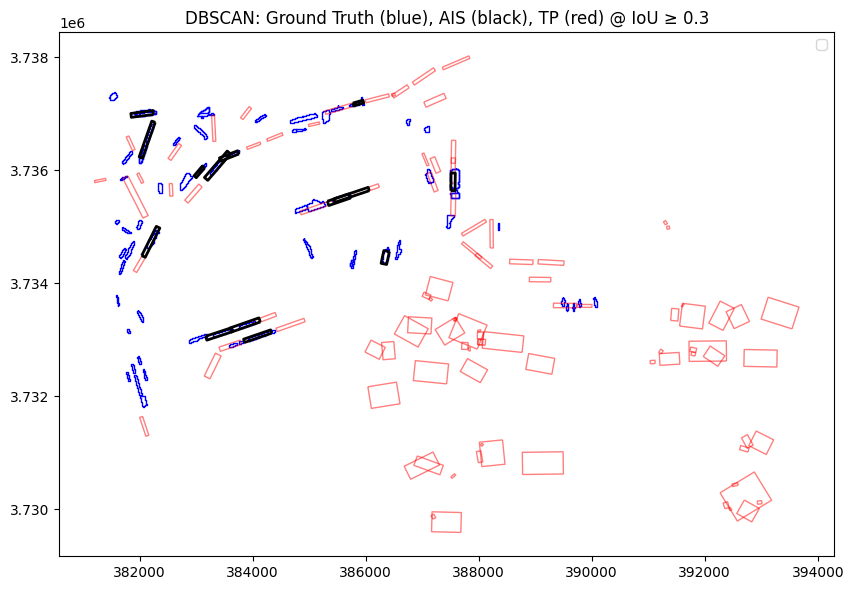

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


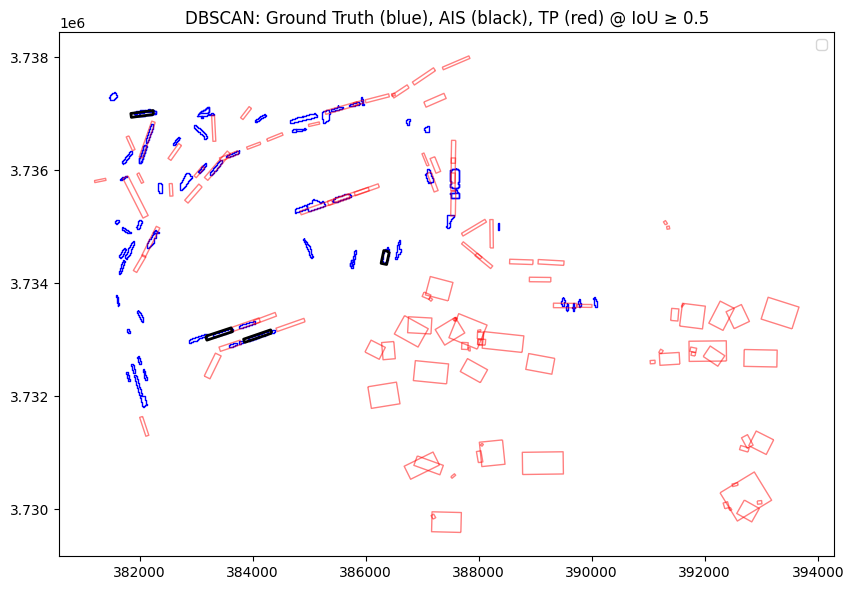

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,DBSCAN,0.05,22,90,53,0.196429,0.293333,0.235294
1,DBSCAN,0.01,23,89,53,0.205357,0.302632,0.244681
2,DBSCAN,0.30,14,98,60,0.125000,0.189189,0.150538
3,DBSCAN,0.50,4,108,69,0.035714,0.054795,0.043243


In [31]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.01, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once(
    method_name="DBSCAN",
    ais_html_path=DBSCAN_html_path,
    gt_gpkg_path=sam_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]


### C. Validation of Spectral against SAM

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


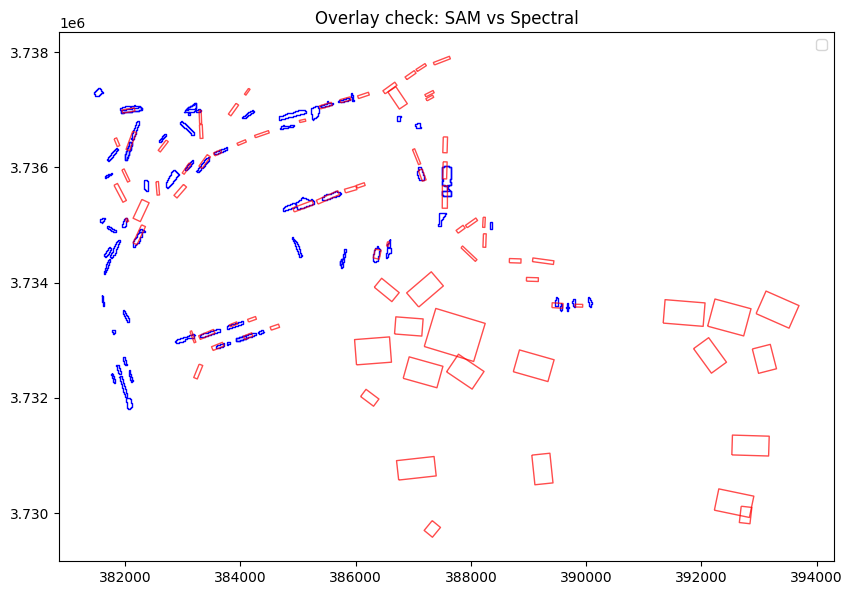

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


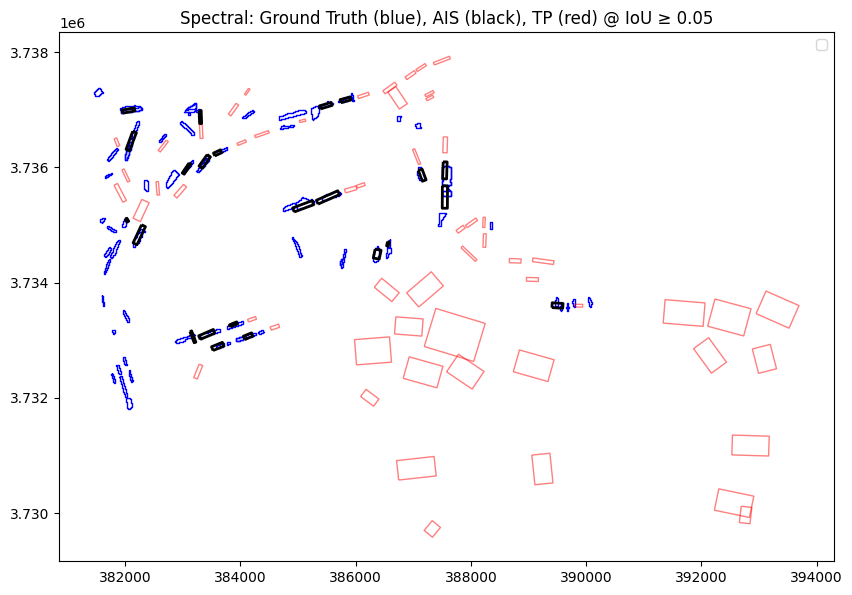

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


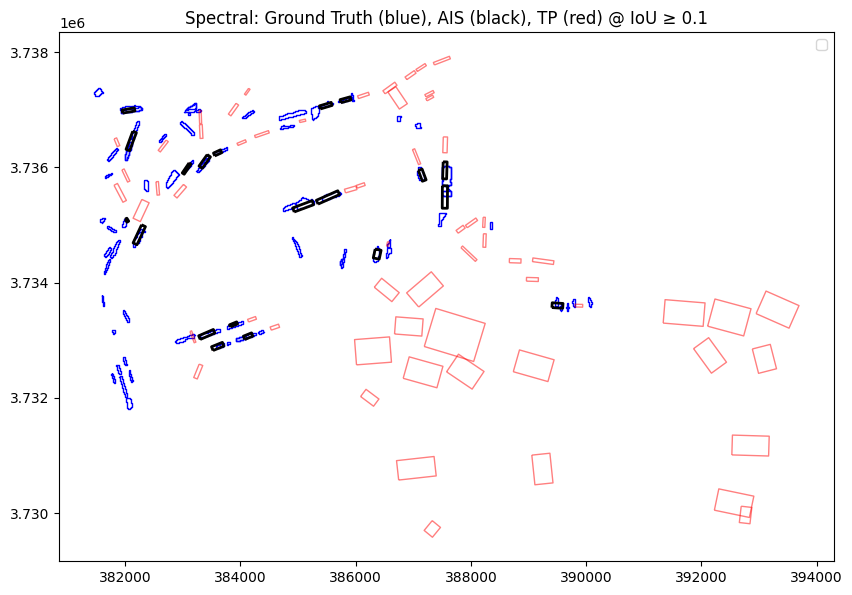

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


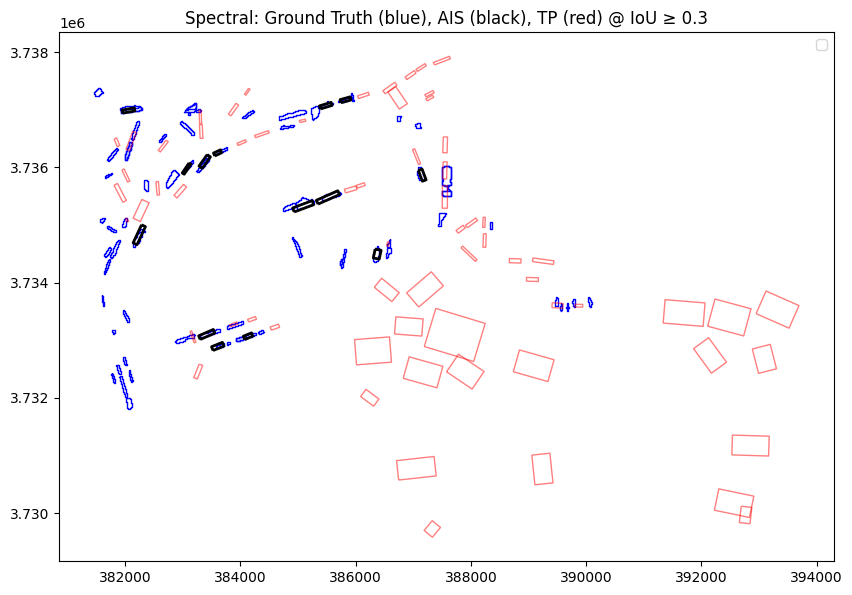

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


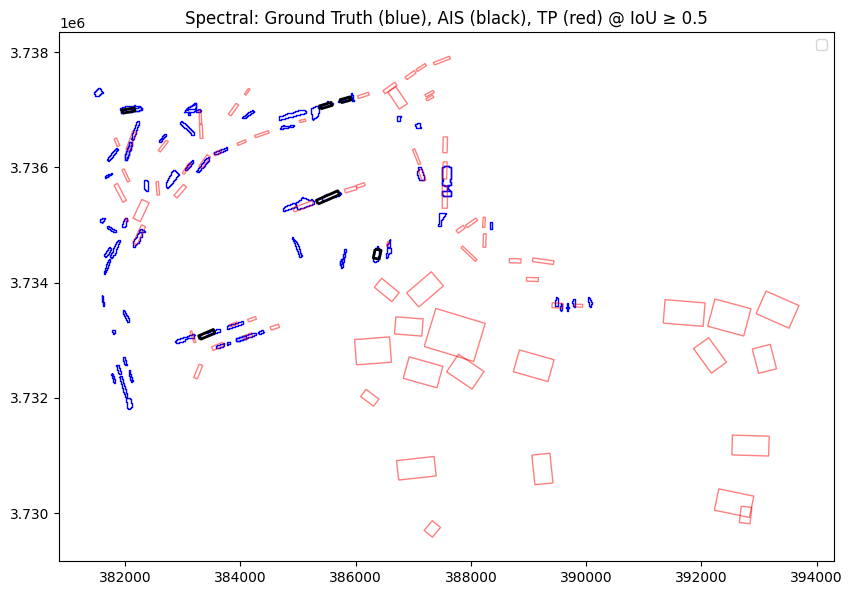

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,Spectral,0.05,23,57,50,0.2875,0.315068,0.300654
1,Spectral,0.10,20,60,53,0.2500,0.273973,0.261438
2,Spectral,0.30,14,66,59,0.1750,0.191781,0.183007
3,Spectral,0.50,6,74,67,0.0750,0.082192,0.078431


In [32]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.10, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once(
    method_name="Spectral",
    ais_html_path=Spectral_html_path,
    gt_gpkg_path=sam_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]


## Validation of AIS without Anchorage Spots against SAM

### A. Validation of Kmeans without anchor against SAM

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


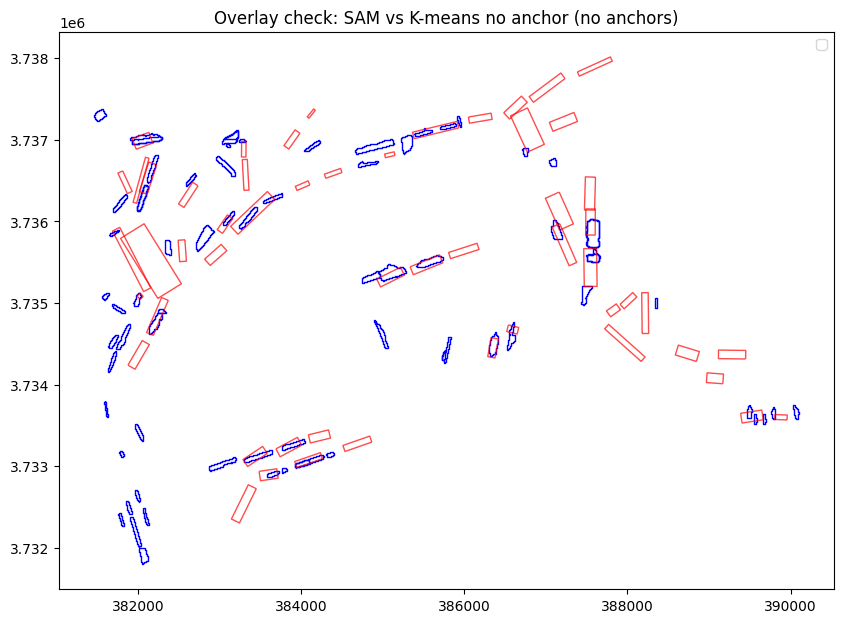

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


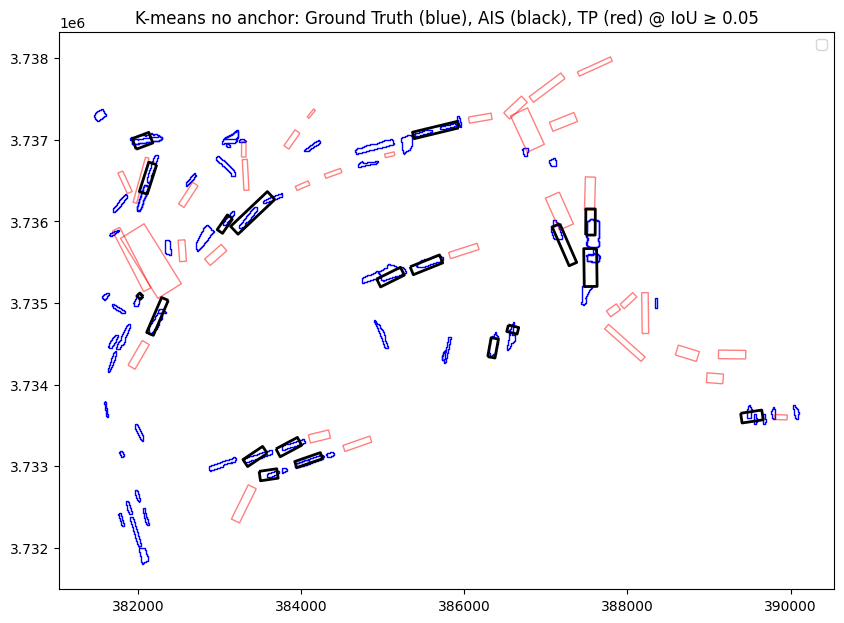

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


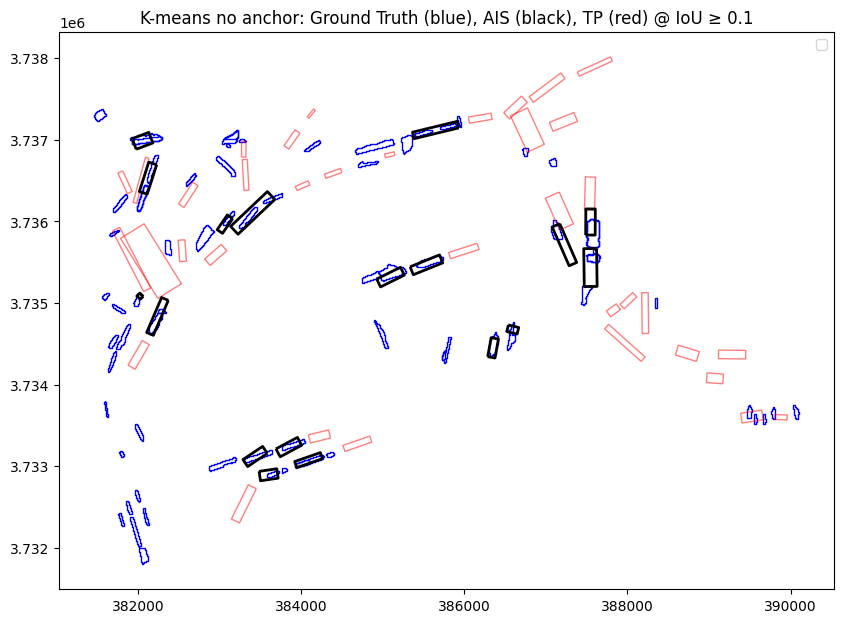

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


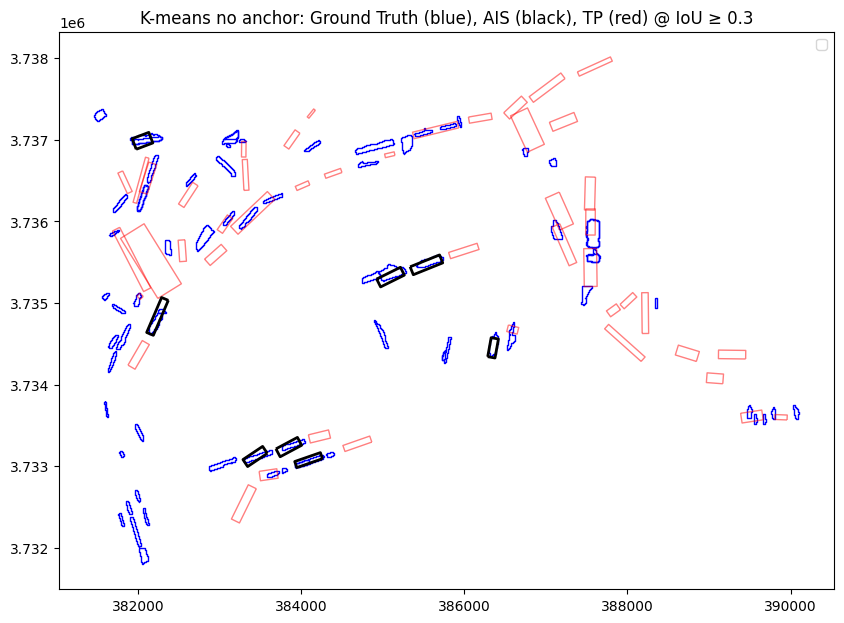

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


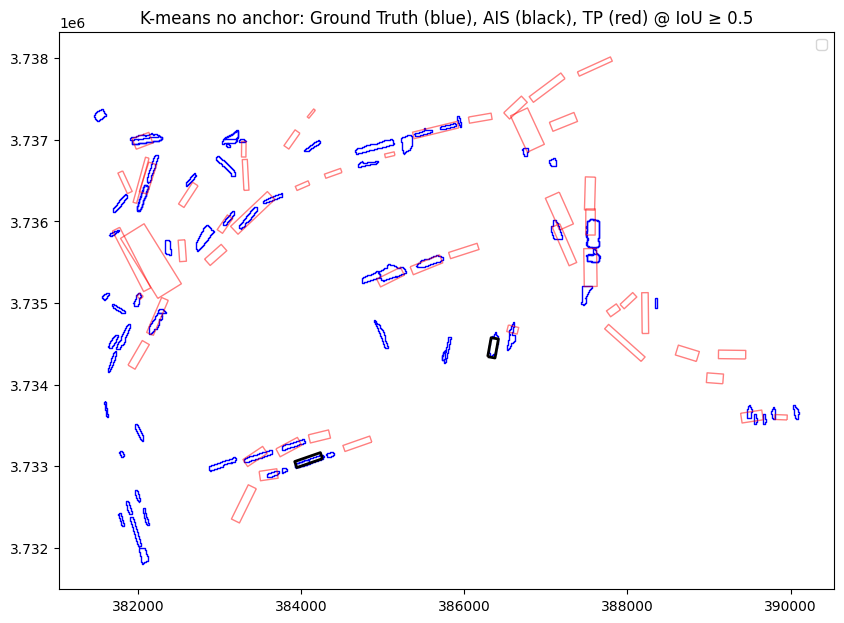

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,K-means no anchor,0.05,19,35,54,0.351852,0.260274,0.299213
1,K-means no anchor,0.10,18,36,55,0.333333,0.246575,0.283465
2,K-means no anchor,0.30,8,46,65,0.148148,0.109589,0.125984
3,K-means no anchor,0.50,2,52,71,0.037037,0.027397,0.031496


In [33]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.10, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once_gpkg(
    method_name="K-means no anchor",
    ais_gpkg_path=kmeans_gpkg_no_anchor,
    gt_gpkg_path=sam_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]


### B. Validation of DBSCAN without anchor against SAM

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


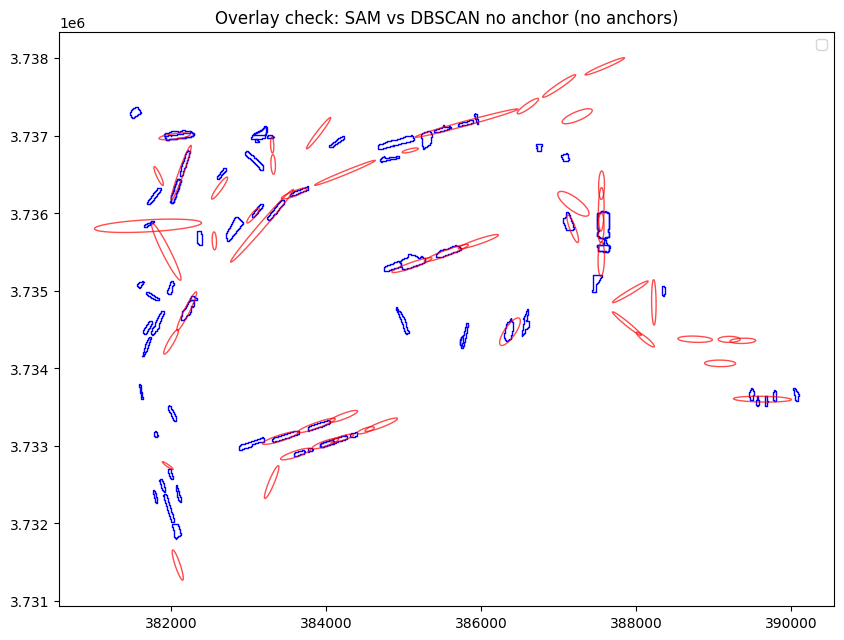

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


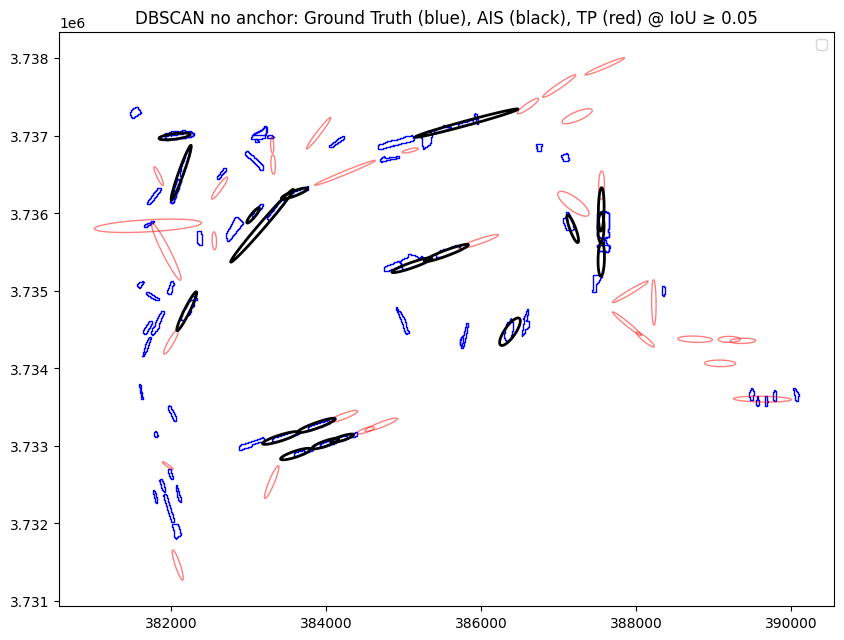

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


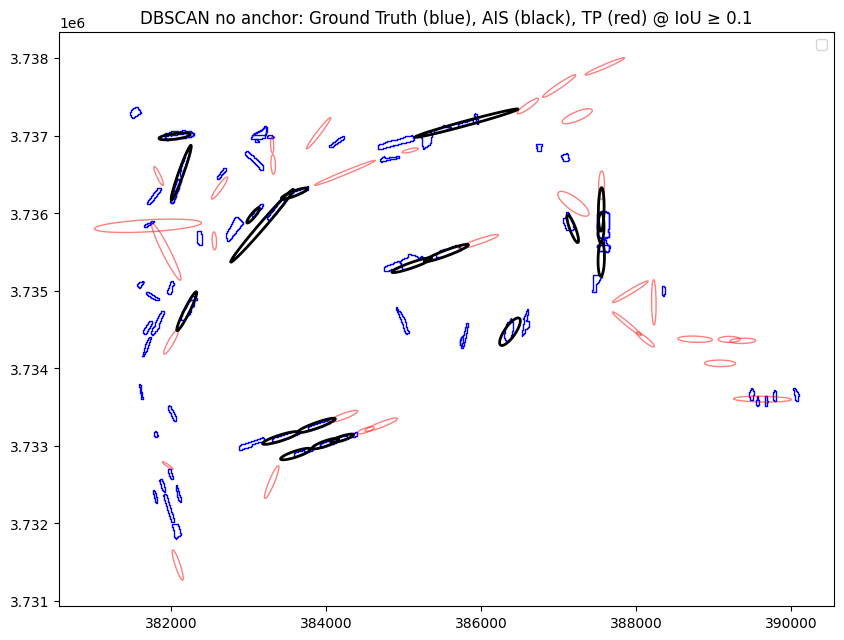

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


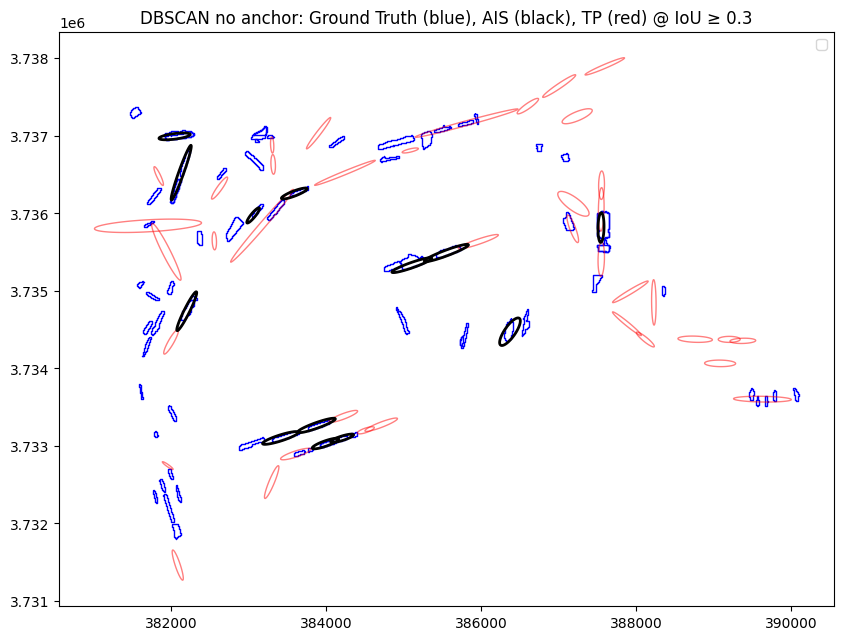

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


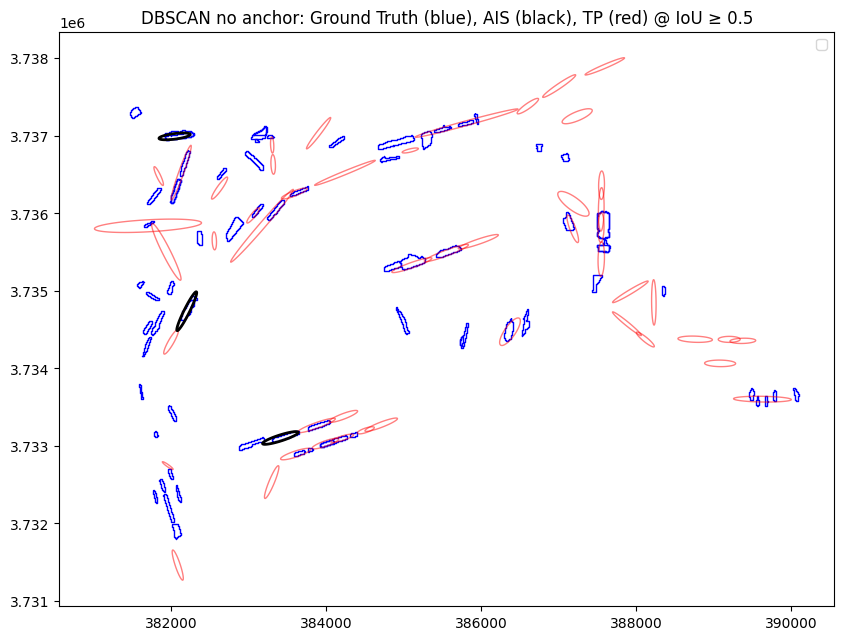

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,DBSCAN no anchor,0.05,19,33,55,0.365385,0.256757,0.301587
1,DBSCAN no anchor,0.10,19,33,55,0.365385,0.256757,0.301587
2,DBSCAN no anchor,0.30,13,39,60,0.250000,0.178082,0.208000
3,DBSCAN no anchor,0.50,3,49,70,0.057692,0.041096,0.048000


In [34]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.10, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once_gpkg(
    method_name="DBSCAN no anchor",
    ais_gpkg_path=DBSCAN_gpkg_no_anchor,
    gt_gpkg_path=sam_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]

### C. Validation of Spectral without anchor against SAM

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


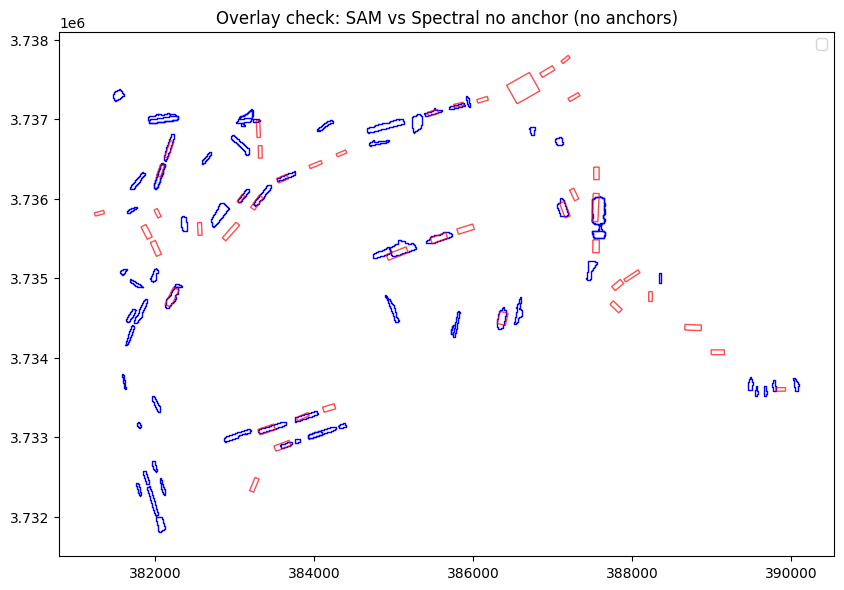

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


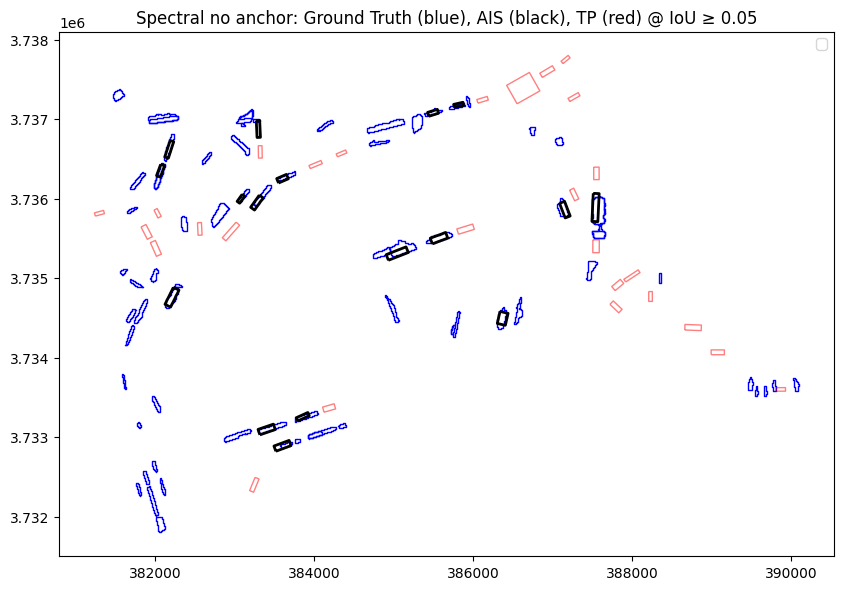

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


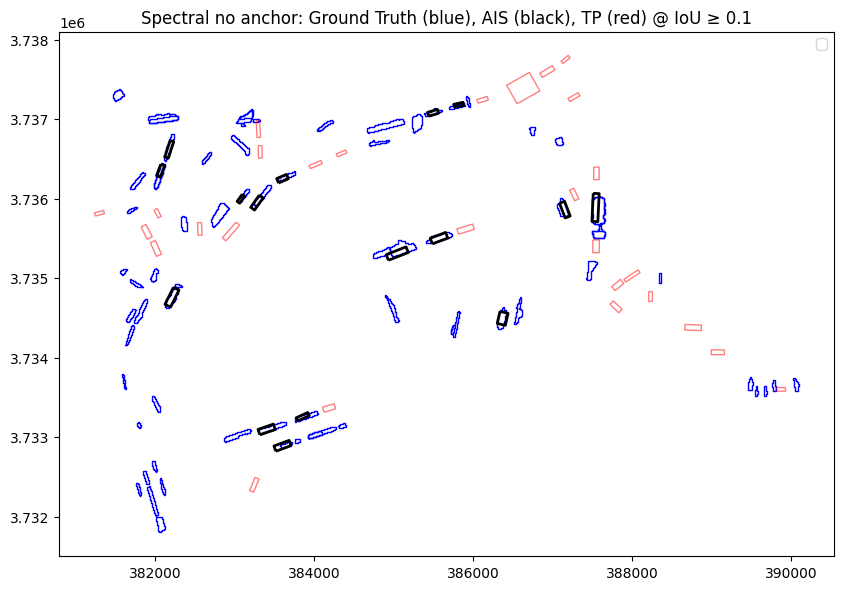

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


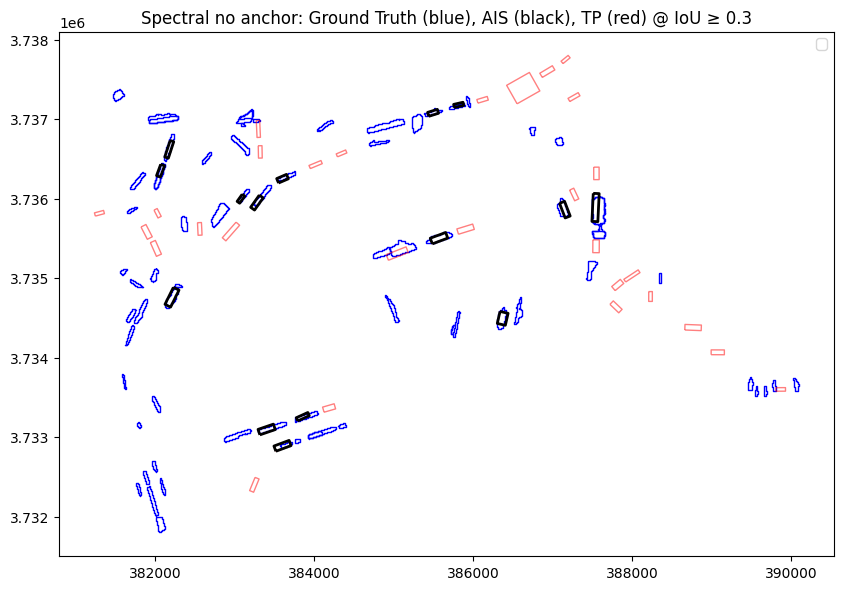

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


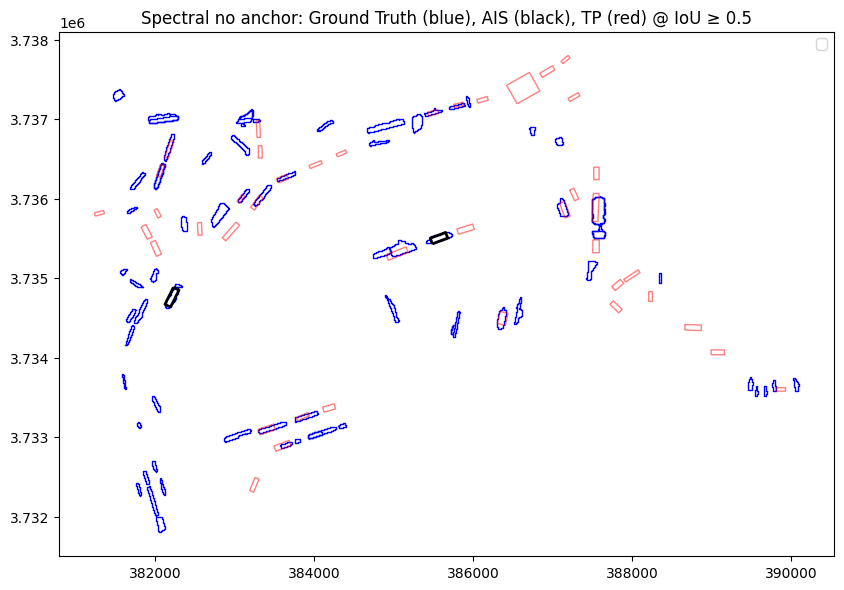

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,Spectral no anchor,0.05,17,27,56,0.386364,0.232877,0.290598
1,Spectral no anchor,0.10,16,28,57,0.363636,0.219178,0.273504
2,Spectral no anchor,0.30,15,29,58,0.340909,0.205479,0.256410
3,Spectral no anchor,0.50,2,42,71,0.045455,0.027397,0.034188


In [35]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.10, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once_gpkg(
    method_name="Spectral no anchor",
    ais_gpkg_path=Spectral_gpkg_no_anchor,
    gt_gpkg_path=sam_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]

# Validation with ShipNext

## Validation of AIS against ShipNext

### A. Validation of Kmeans against ShipNext

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


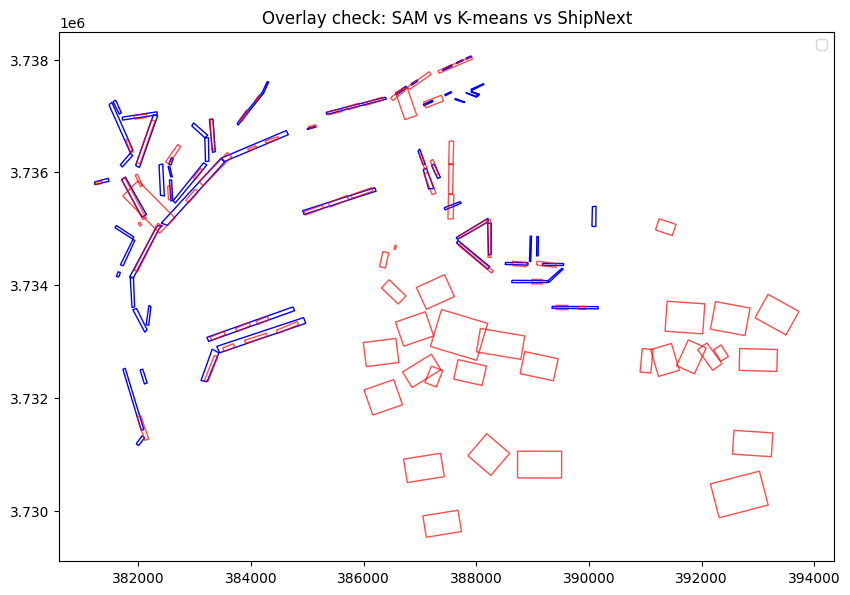

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


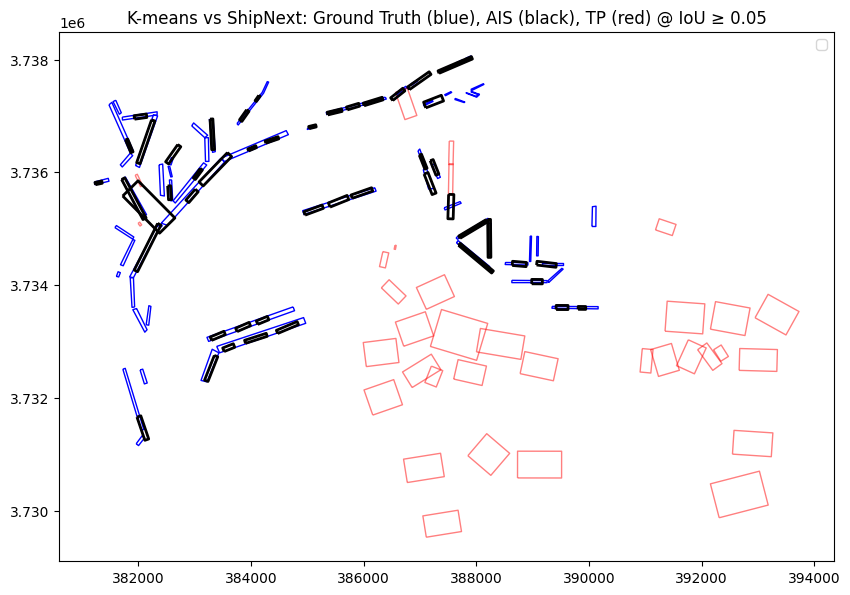

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


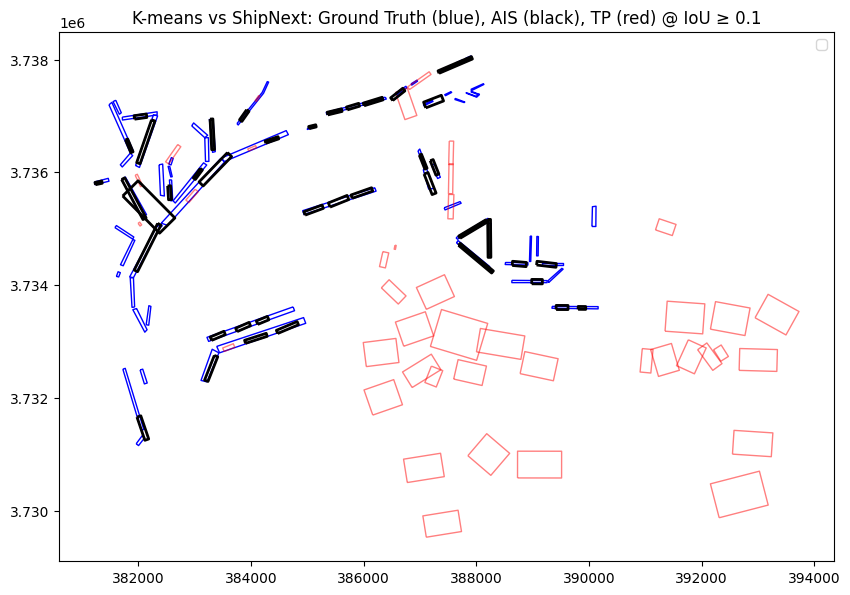

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


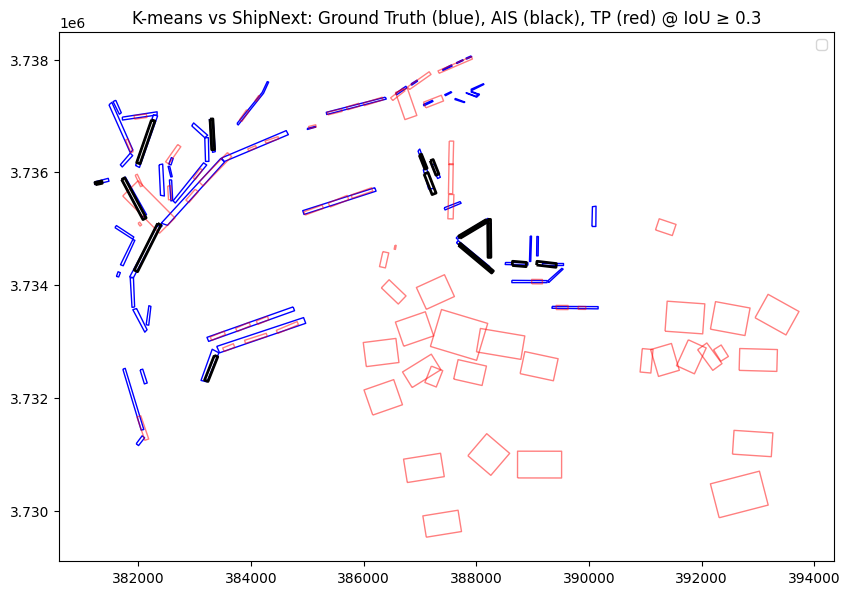

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


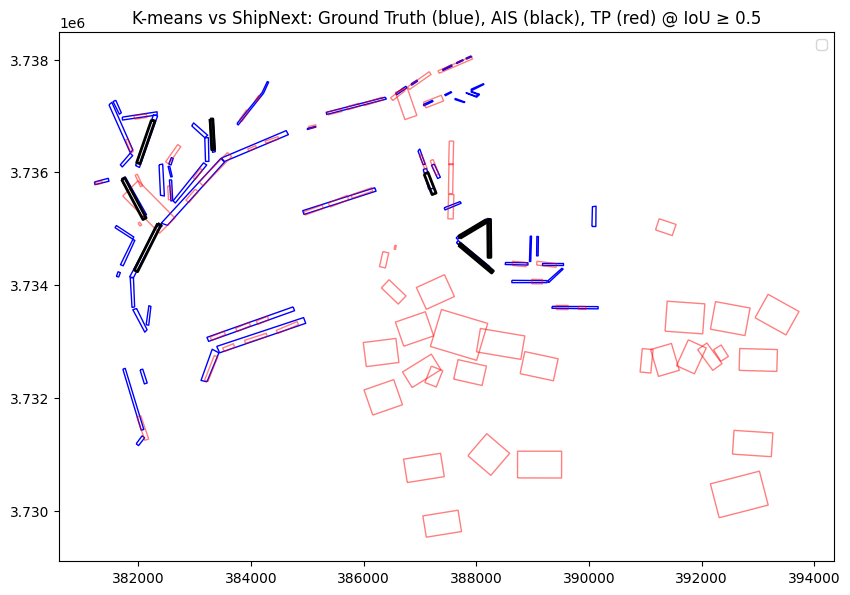

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,K-means vs ShipNext,0.05,48,34,26,0.585366,0.648649,0.615385
1,K-means vs ShipNext,0.10,41,41,29,0.500000,0.585714,0.539474
2,K-means vs ShipNext,0.30,14,68,47,0.170732,0.229508,0.195804
3,K-means vs ShipNext,0.50,8,74,53,0.097561,0.131148,0.111888


In [36]:
METRIC_CRS = "EPSG:32611"
IOU_THRESHOLDS = [0.05, 0.10, 0.30, 0.50]

# Prepare once (overlay only once)
prepared = prepare_validation_once(
    method_name="K-means vs ShipNext",
    ais_html_path=kmeans_html_path,
    gt_gpkg_path=shipnext_gpkg,
    metric_crs=METRIC_CRS,
    do_overlay_plot=True,
)

# Evaluate many thresholds (no overlay repeated)
results = []
for thr in IOU_THRESHOLDS:
    results.append(evaluate_threshold(prepared, iou_threshold=thr, make_tp_plot=True))

summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]


### B. Validation of DBSCAN against ShipNext

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


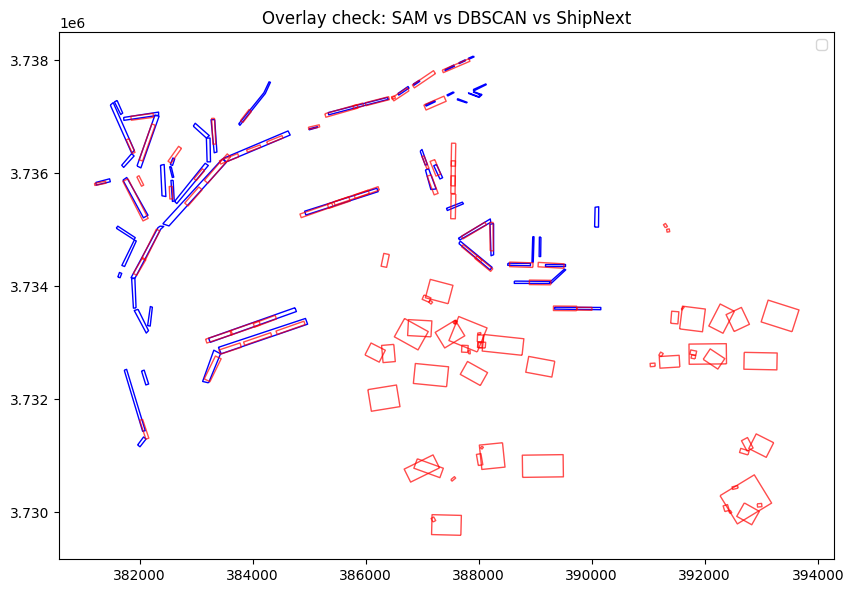

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


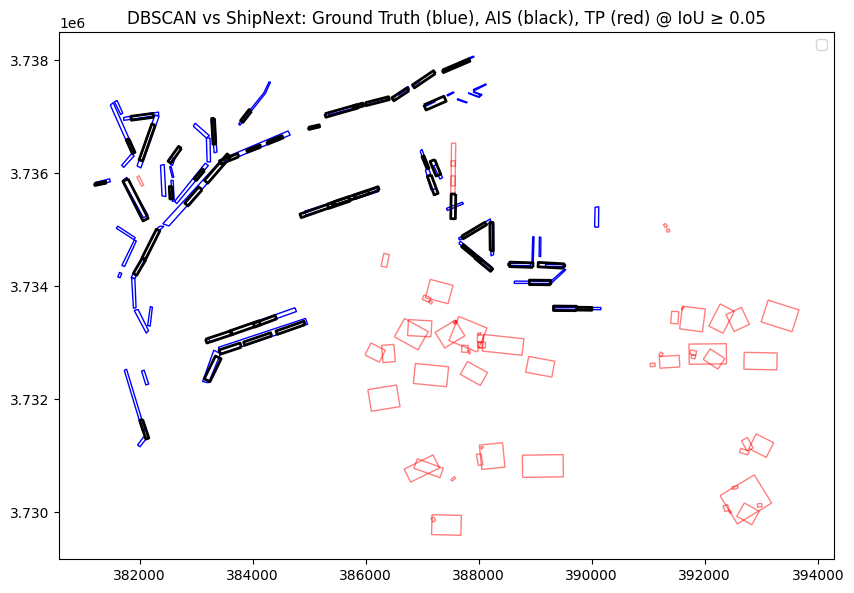

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


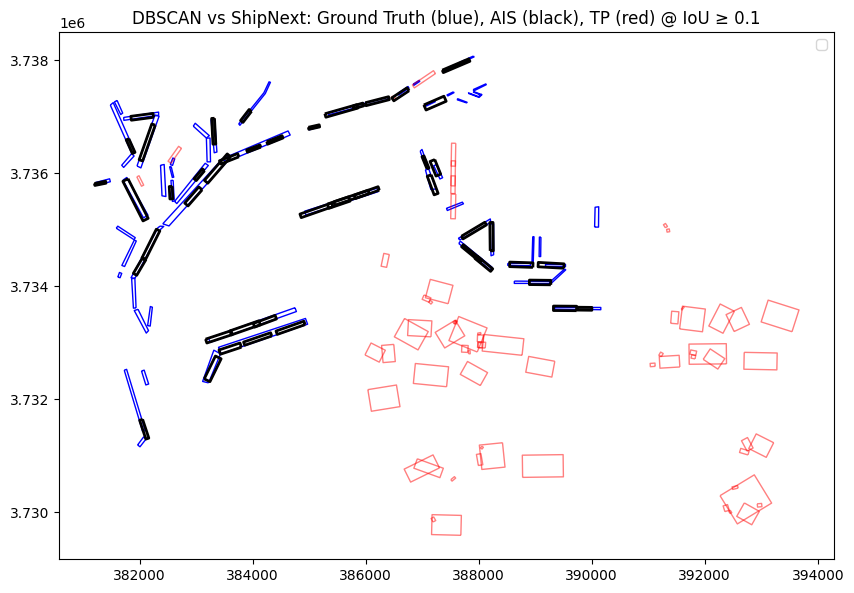

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


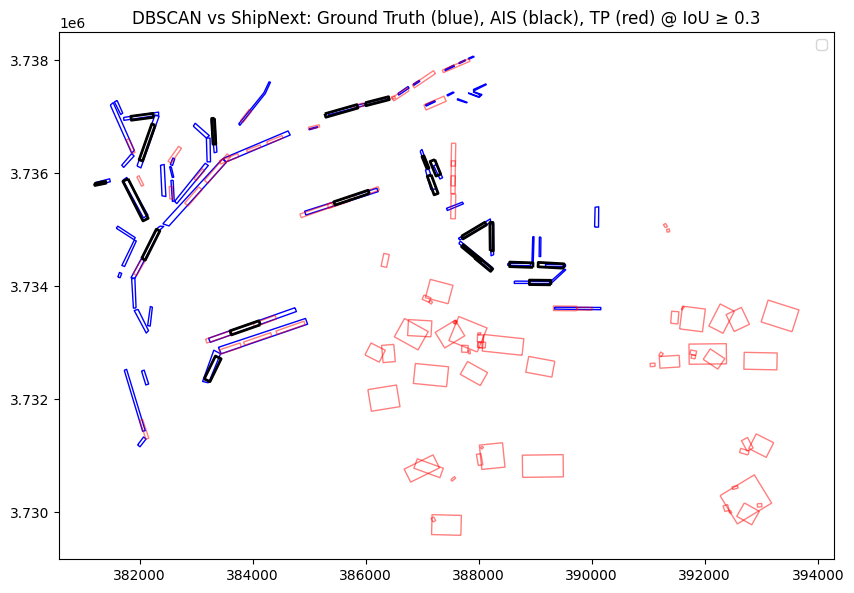

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


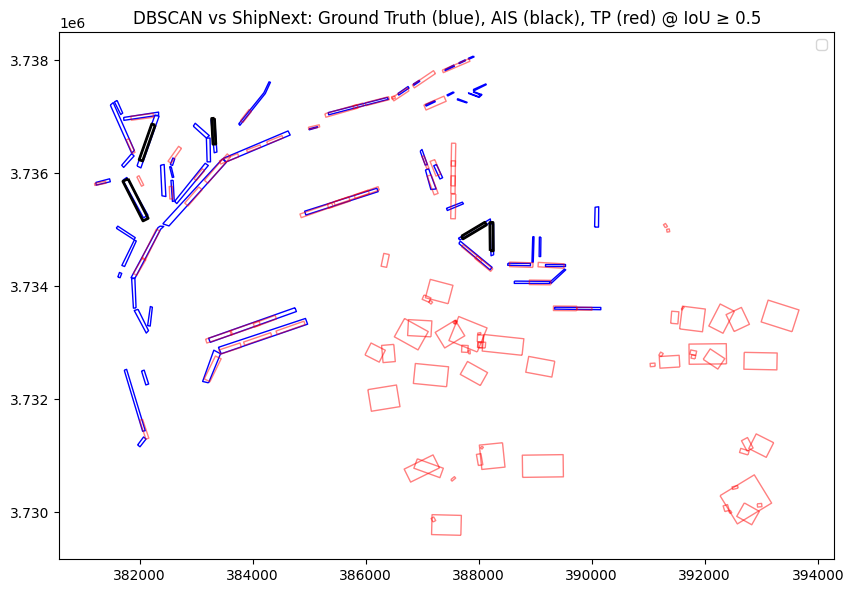

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,DBSCAN vs ShipNext,0.05,50,62,26,0.446429,0.657895,0.531915
1,DBSCAN vs ShipNext,0.10,47,65,29,0.419643,0.618421,0.500000
2,DBSCAN vs ShipNext,0.30,21,91,42,0.187500,0.333333,0.240000
3,DBSCAN vs ShipNext,0.50,5,107,56,0.044643,0.081967,0.057803


In [37]:
METRIC_CRS = "EPSG:32611"
IOU_THRESHOLDS = [0.05, 0.10, 0.30, 0.50]

# Prepare once (overlay only once)
prepared = prepare_validation_once(
    method_name="DBSCAN vs ShipNext",
    ais_html_path=DBSCAN_html_path,
    gt_gpkg_path=shipnext_gpkg,
    metric_crs=METRIC_CRS,
    do_overlay_plot=True,
)

# Evaluate many thresholds (no overlay repeated)
results = []
for thr in IOU_THRESHOLDS:
    results.append(evaluate_threshold(prepared, iou_threshold=thr, make_tp_plot=True))

summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]

### C. Validation of Spectral against ShipNext

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


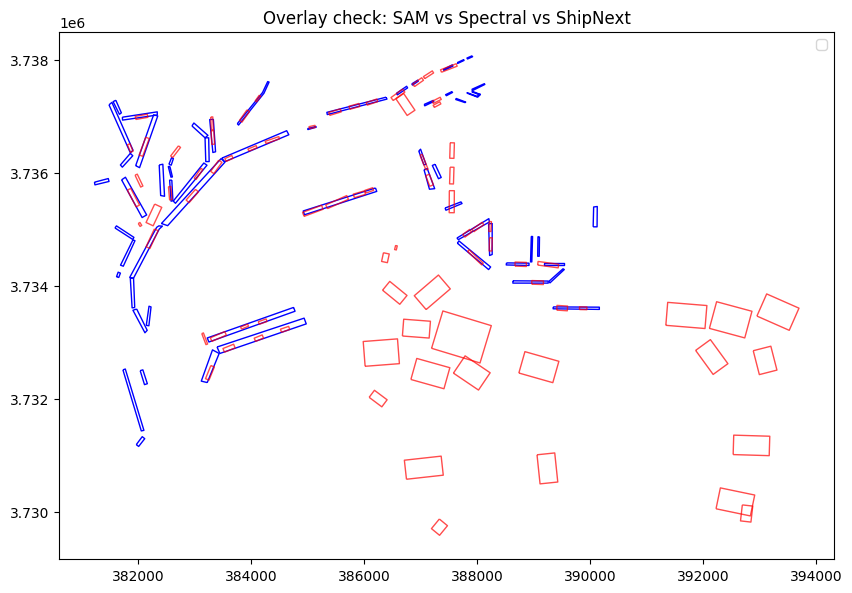

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


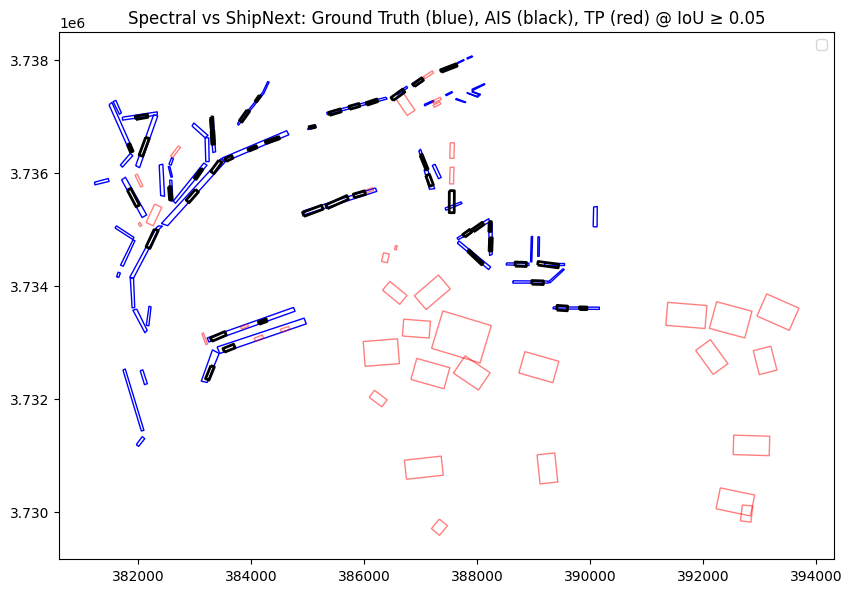

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


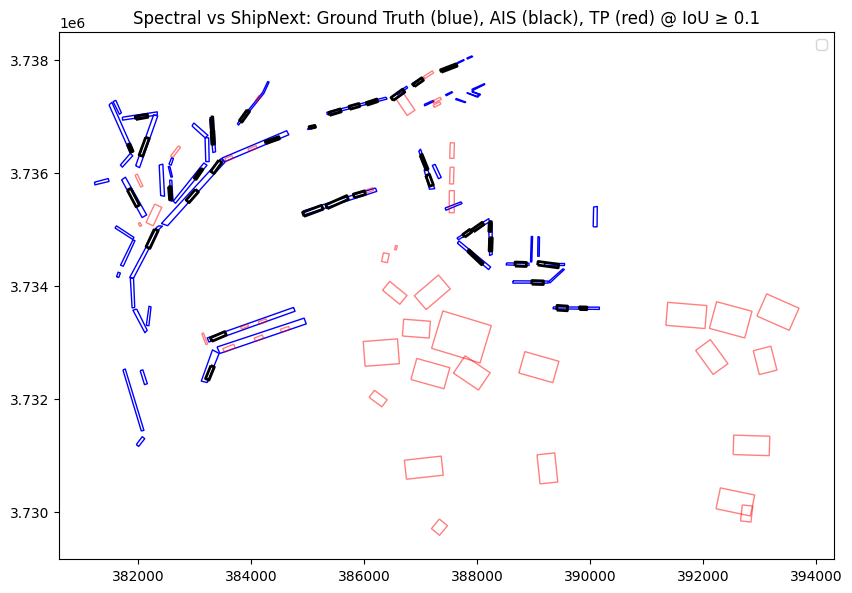

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


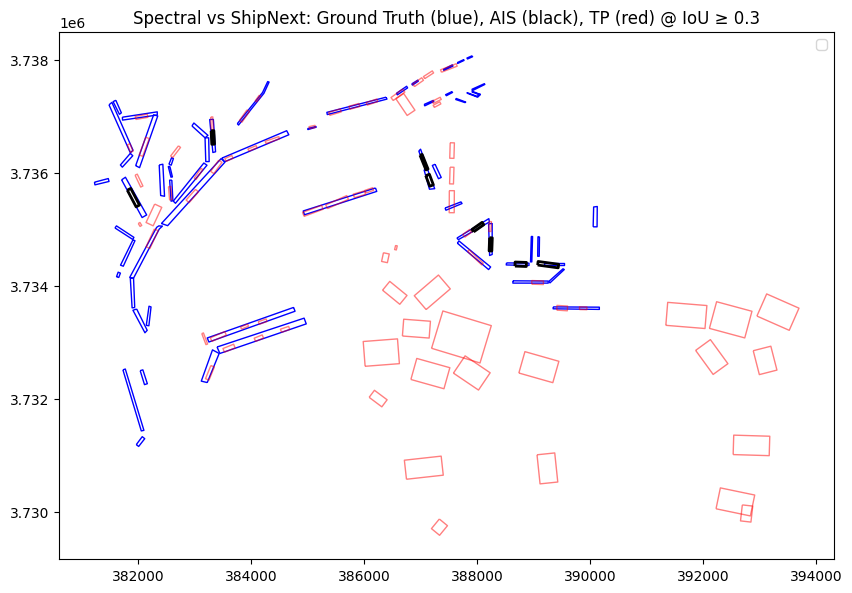

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:220: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  ais_plot[ais_plot["is_tp"]].plot(ax=ax, edgecolor="black", facecolor="none", linewidth=2, label="TP (black)")
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


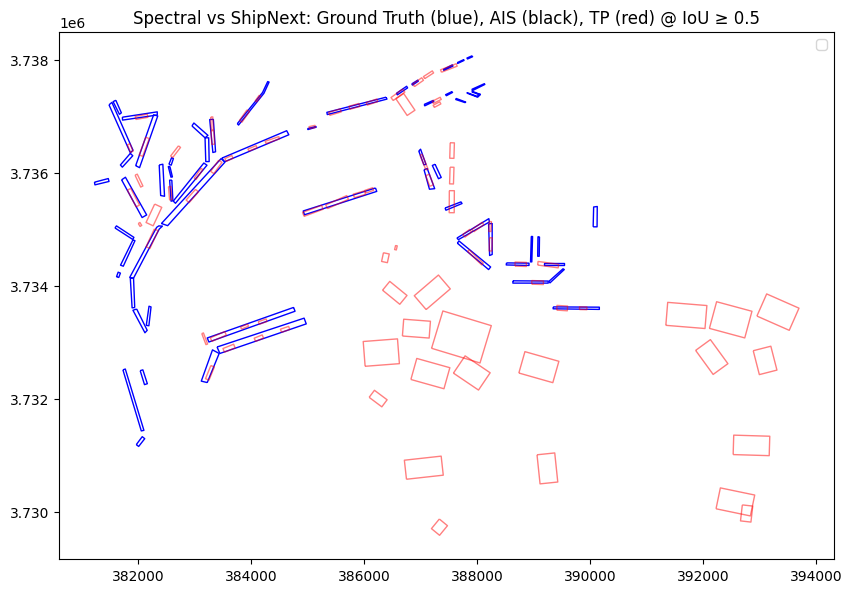

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,Spectral vs ShipNext,0.05,43,37,31,0.5375,0.581081,0.558442
1,Spectral vs ShipNext,0.10,37,43,33,0.4625,0.528571,0.493333
2,Spectral vs ShipNext,0.30,8,72,53,0.1000,0.131148,0.113475
3,Spectral vs ShipNext,0.50,0,80,61,0.0000,0.000000,0.000000


In [38]:
METRIC_CRS = "EPSG:32611"
IOU_THRESHOLDS = [0.05, 0.10, 0.30, 0.50]

# Prepare once (overlay only once)
prepared = prepare_validation_once(
    method_name="Spectral vs ShipNext",
    ais_html_path=Spectral_html_path,
    gt_gpkg_path=shipnext_gpkg,
    metric_crs=METRIC_CRS,
    do_overlay_plot=True,
)

# Evaluate many thresholds (no overlay repeated)
results = []
for thr in IOU_THRESHOLDS:
    results.append(evaluate_threshold(prepared, iou_threshold=thr, make_tp_plot=True))

summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]

## Validation of AIS without Anchor against ShipNext

### A. Validation of Kmeans without anchor against ShipNext

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


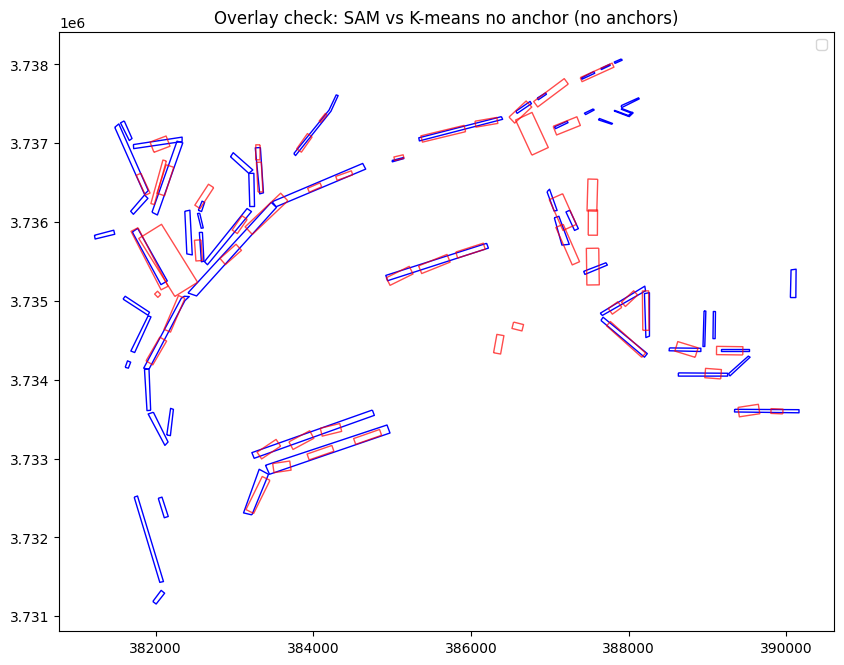

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


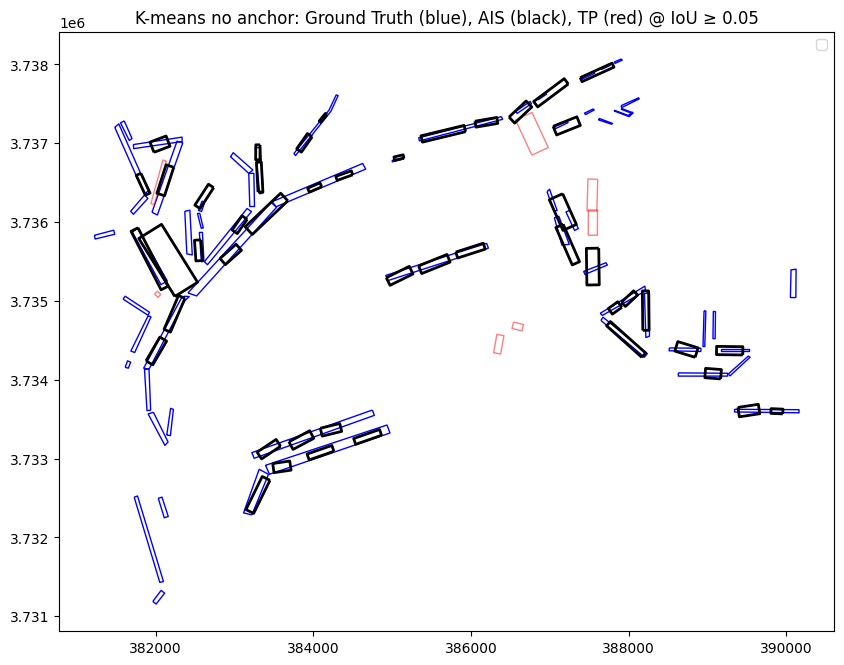

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


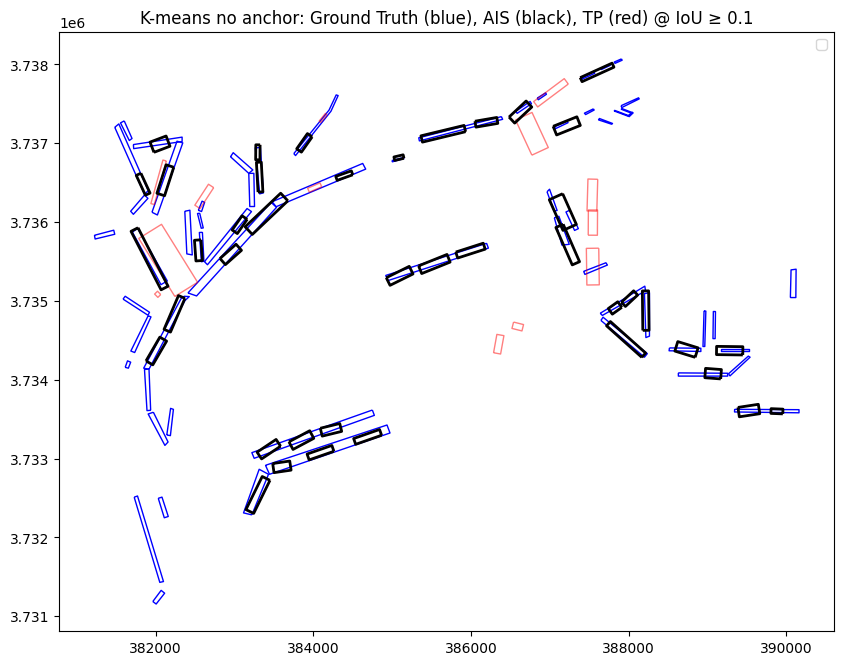

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


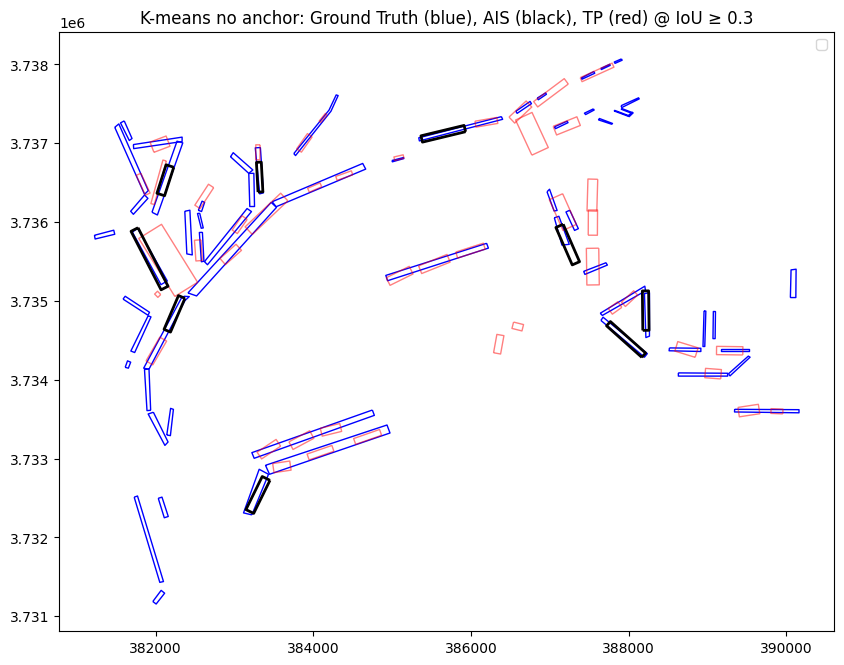

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


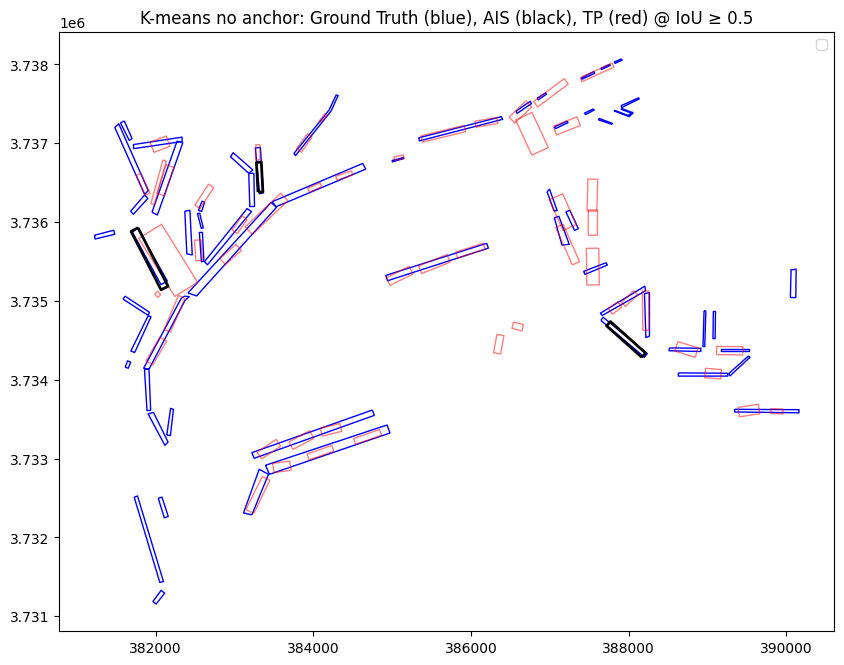

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,K-means no anchor,0.05,47,7,29,0.870370,0.618421,0.723077
1,K-means no anchor,0.10,41,13,32,0.759259,0.561644,0.645669
2,K-means no anchor,0.30,9,45,52,0.166667,0.147541,0.156522
3,K-means no anchor,0.50,3,51,58,0.055556,0.049180,0.052174


In [39]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.10, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once_gpkg(
    method_name="K-means no anchor",
    ais_gpkg_path=kmeans_gpkg_no_anchor,
    gt_gpkg_path=shipnext_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]

### B. Validation of GMM without anchor against ShipNext

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


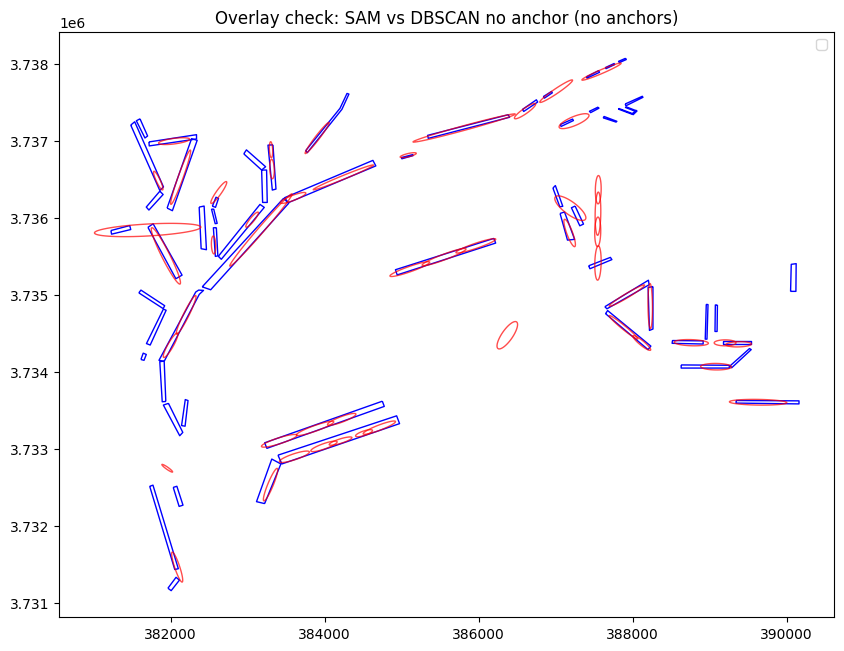

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


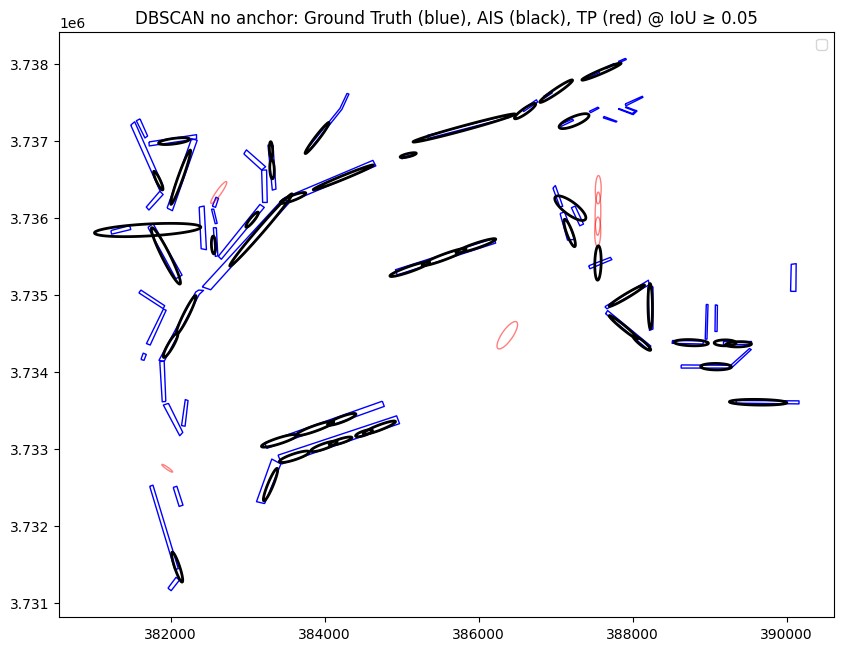

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


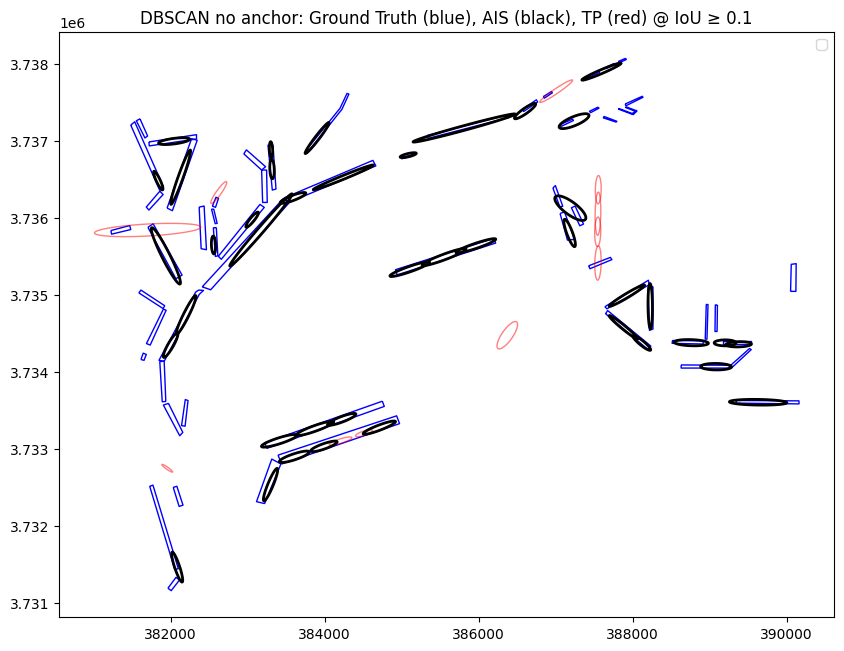

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


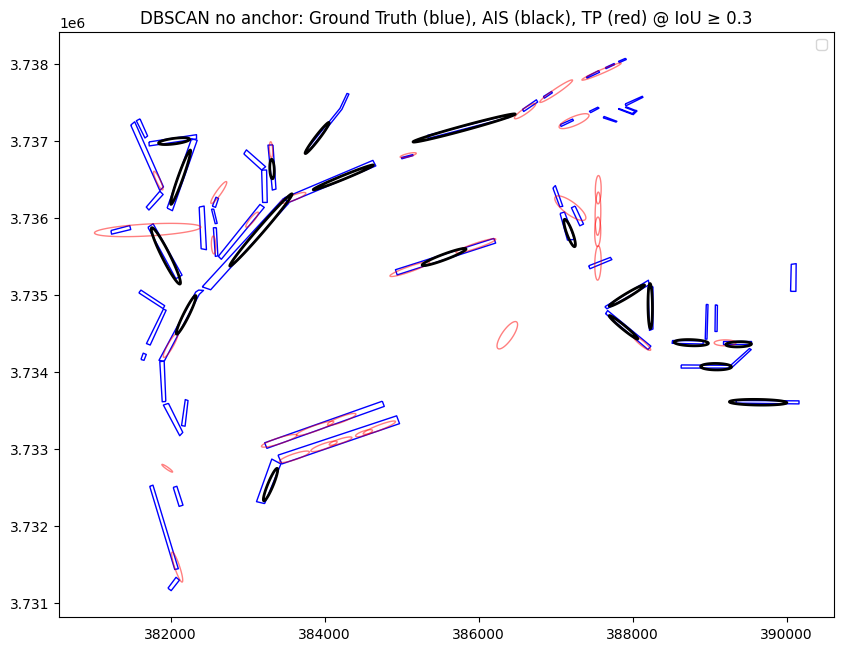

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


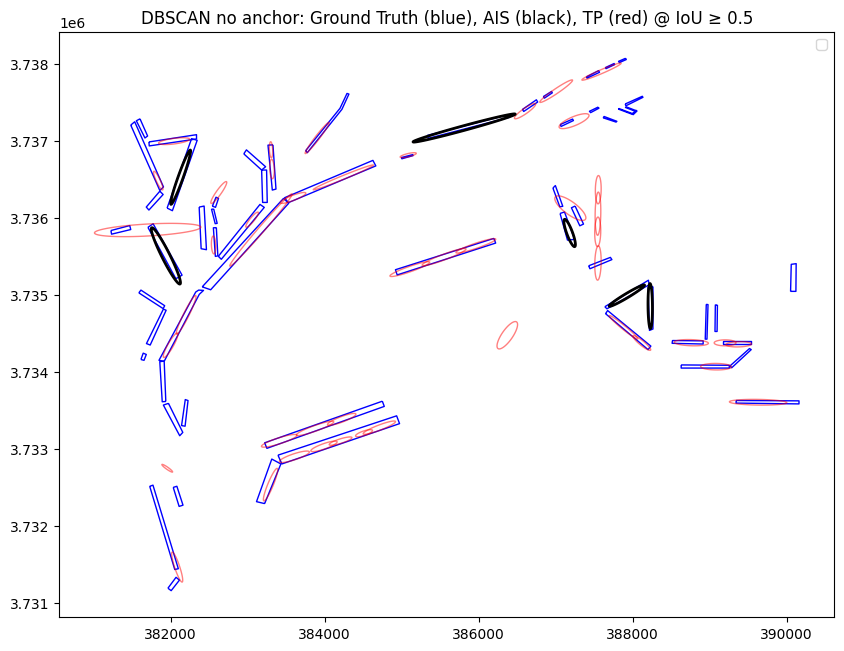

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,DBSCAN no anchor,0.05,46,6,28,0.884615,0.621622,0.730159
1,DBSCAN no anchor,0.10,41,11,31,0.788462,0.569444,0.661290
2,DBSCAN no anchor,0.30,19,33,42,0.365385,0.311475,0.336283
3,DBSCAN no anchor,0.50,6,46,55,0.115385,0.098361,0.106195


In [40]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.10, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once_gpkg(
    method_name="DBSCAN no anchor",
    ais_gpkg_path=DBSCAN_gpkg_no_anchor,
    gt_gpkg_path=shipnext_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]

### C. Validation of Spectral without anchor against ShipNext

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:106: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


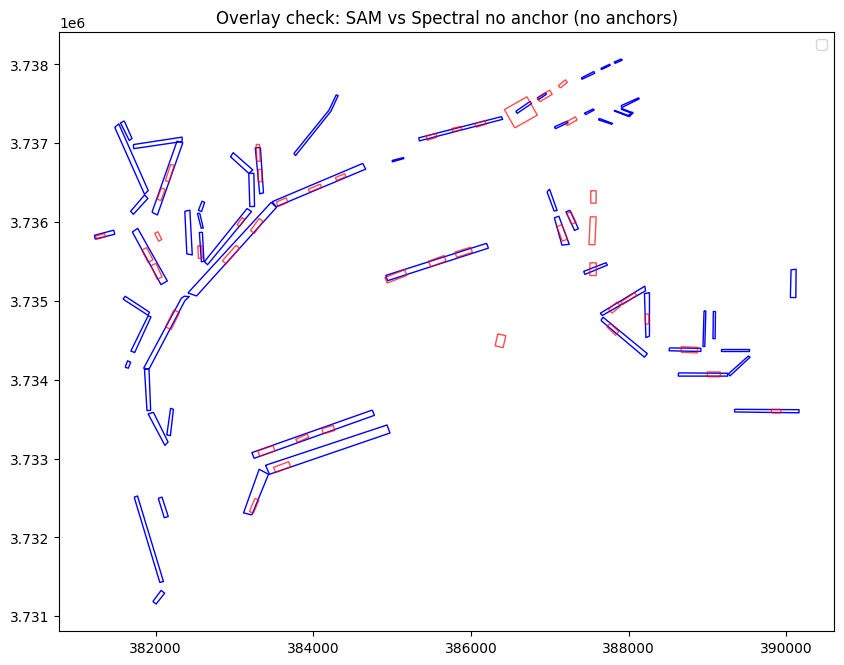

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


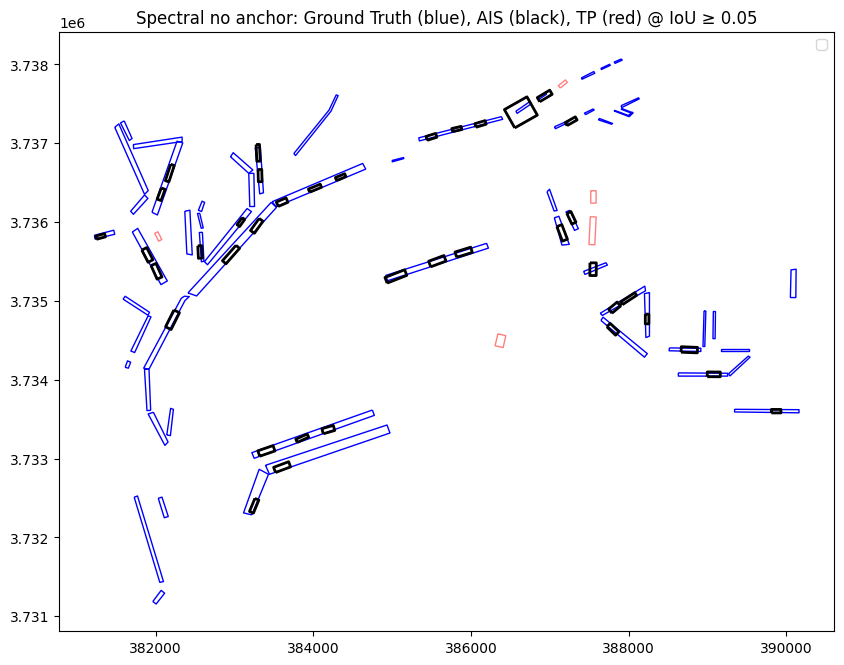

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


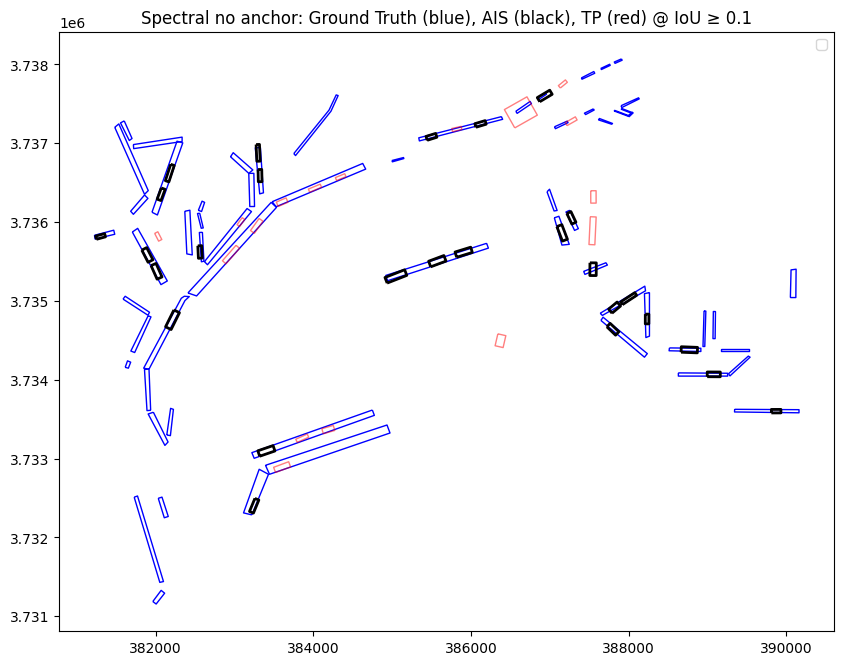

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


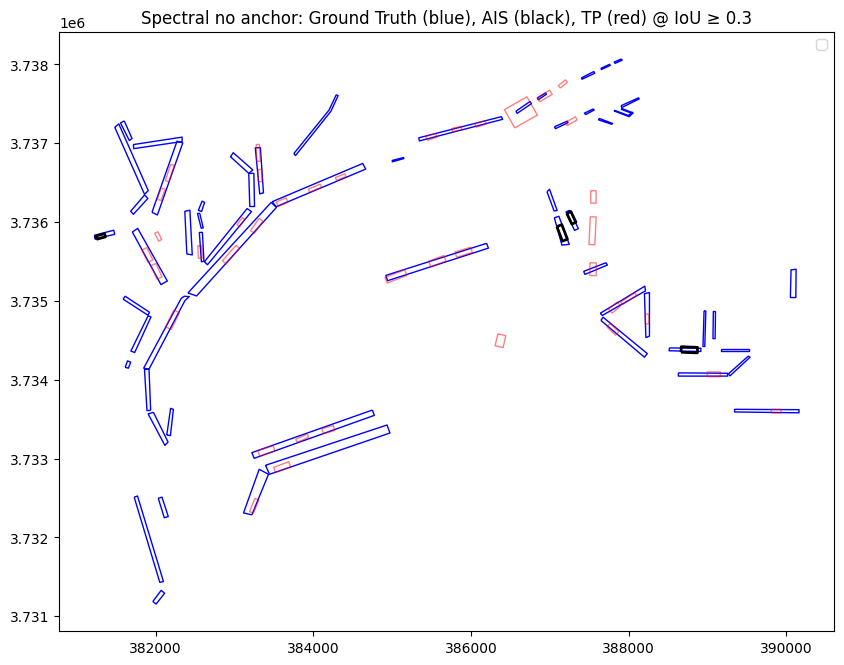

/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
/var/folders/nz/z5__zj816_l57z42hv_bc17c0000gn/T/ipykernel_3745/227703109.py:223: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


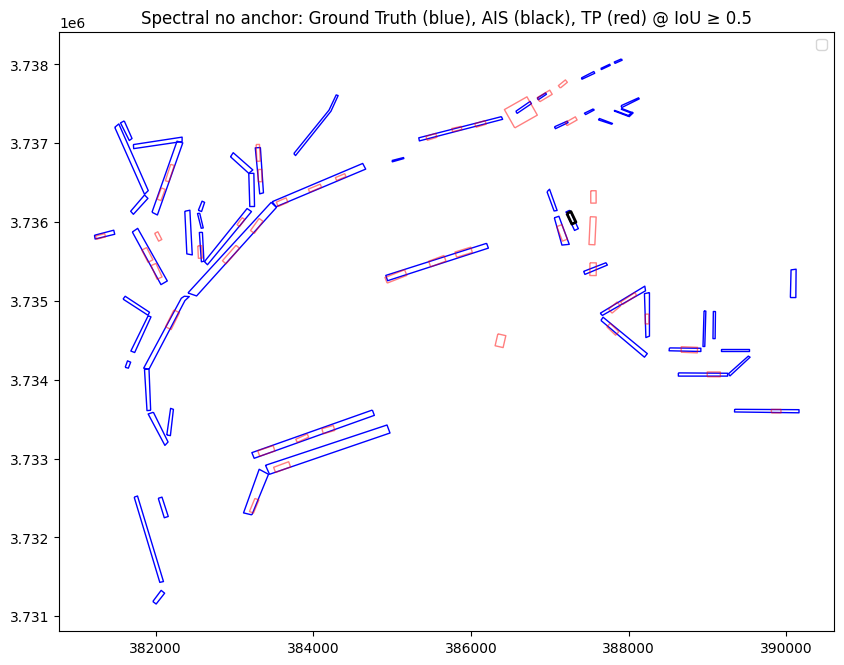

,method,iou_threshold,tp,fp,fn,precision,recall,f1
0,Spectral no anchor,0.05,39,5,35,0.886364,0.527027,0.661017
1,Spectral no anchor,0.10,27,17,41,0.613636,0.397059,0.482143
2,Spectral no anchor,0.30,4,40,57,0.090909,0.065574,0.076190
3,Spectral no anchor,0.50,1,43,60,0.022727,0.016393,0.019048


In [41]:
Metric_CRS = "EPSG:32611"
Iou_Threshold = [0.05, 0.10, 0.30, 0.50]

#Run preparation
prepared = prepare_validation_once_gpkg(
    method_name="Spectral no anchor",
    ais_gpkg_path=Spectral_gpkg_no_anchor,
    gt_gpkg_path=shipnext_gpkg,
    metric_crs=Metric_CRS,
    do_overlay_plot=True,
)

#Evaluate for thresholds
results = []
for thr in Iou_Threshold:
    result = evaluate_threshold(
        prepared=prepared,
        iou_threshold=thr,
        make_tp_plot=True
    )
    results.append(result)

#Make a summary table
summary = pd.DataFrame([r["metrics"] | {"method": prepared["method"]} for r in results])
summary[["method", "iou_threshold", "tp", "fp", "fn", "precision", "recall", "f1"]]